[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter4_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 4: Seasonality and forecasting: SARIMA, TBATS, Prophet

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Seasonal data from Romania (Eurostat, ENTSO-E); seasonal differences and seasonal unit roots (HEGY, OCSB, Canova–Hansen).
- SARIMA$(p,d,q)(P,D,Q)_s$: theory, the airline model, Romanian GDP; seasonal adjustment (NSA and SCA series).
- Fourier terms and calendar effects (Orthodox Easter, working days); multiple seasonality in electricity load: MSTL, dynamic harmonic regression, TBATS, Prophet.
- Time-series cross-validation, MASE, the Diebold–Mariano test and forecast combination.
- References: Huang and Petukhina (2022), Ch. 4–5; Hyndman and Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.), Ch. 9, 10, 12, 13; Box, Jenkins and Reinsel (2008), Ch. 9.
- TBATS and Prophet are optional packages: the first code cell installs them if they are missing (about a minute in Colab).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_4'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# Optional packages (TBATS, Prophet, pmdarima): installed only if missing (about one minute in Colab)
import importlib.util, subprocess, sys
for pkg in ['tbats', 'prophet']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions used in the whole notebook

- SARIMA: $\phi(L)\Phi(L^s)(1-L)^d(1-L^s)^D y_t = \theta(L)\Theta(L^s)\varepsilon_t$; `fit_sarima(y, order, sorder)` is exact Gaussian maximum likelihood (`statsmodels` `SARIMAX`).
- `ro_holidays(years)`: Romanian public holidays, with Orthodox Easter and Pentecost from `dateutil`.
- `load_hourly()`, `load_daily()`: electricity load of Romania (ENTSO-E), in Romanian winter time (UTC+2).
- `fourier(idx, period, K)`: Fourier terms; `easter_share(idx, w)`: the Easter regressor; `working_days(idx)`.

In [6]:
import logging
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import MSTL
from statsmodels.regression.linear_model import OLS
from dateutil.easter import easter, EASTER_ORTHODOX
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
SEED = 2026
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_SCA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
RETAIL = ('sts_trtu_m', 'M.VOL_SLS.G47.NSA.I21.RO')
RETAIL_SCA = ('sts_trtu_m', 'M.VOL_SLS.G47.SCA.I21.RO')
FOOD = ('sts_trtu_m', 'M.VOL_SLS.G47_FOOD.NSA.I21.RO')
IPI = ('sts_inpr_m', 'M.PRD.B-D.NSA.I21.RO')
TOUR = ('tour_occ_nim', 'M.TOTAL.NR.I551-I553.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
GDP_START = '2000-01-01'
ENTSOE = 'https://www.entsoe.eu/publications/data/power-stats/{y}/monthly_hourly_load_values_{y}.csv'
LOAD_FILE = 'ch4_ro_load_hourly.csv'
LOAD_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_04/ch4_ro_load_hourly.csv'
LOAD_YEARS = (2022, 2023, 2024, 2025, 2026)
LOAD_END = '2026-06-30'
CV_FIRST, CV_STEP, CV_H = '2025-06-30', 14, 14
BAND_COL = st.IDAred
MODEL_COL = {'Seasonal naive': st.Amber, 'ETS': st.Teal, 'SARIMA': st.Purple, 'DHR': st.MainBlue, 'TBATS': st.Forest, 'Prophet': st.Orange, 'Combination': st.IDAred}
GDP_GRID = [((0, 1, 1), (0, 1, 1)), ((1, 1, 0), (0, 1, 1)), ((1, 1, 1), (0, 1, 1)), ((0, 1, 2), (0, 1, 1)), ((2, 1, 0), (0, 1, 1)), ((0, 1, 1), (1, 1, 0)), ((1, 1, 0), (1, 1, 0)), ((0, 1, 1), (1, 1, 1)), ((0, 1, 0), (0, 1, 1)), ((0, 1, 1), (0, 1, 0))]
HERE = "."


def have(pkg):
    """True if an optional package (tbats, prophet, pmdarima) is installed."""
    import importlib.util
    return importlib.util.find_spec(pkg) is not None


def eurostat_log(key, start=None):
    """Natural log of a Eurostat series (monthly or quarterly), from `start`."""
    s = np.log(read_eurostat(*key))
    s = s.loc[start:] if start else s
    s.index.freq = None
    return s


def ro_holidays(years):
    """Romanian public holidays (Orthodox Easter and Pentecost from dateutil): date -> name."""
    out = {}
    for y in years:
        e = pd.Timestamp(easter(y, EASTER_ORTHODOX))
        day = pd.Timedelta(days=1)
        hol = {'New Year': [f'{y}-01-01', f'{y}-01-02'], 'Union Day': [f'{y}-01-24'],
               'Easter': [e - 2 * day, e, e + day], 'Labour Day': [f'{y}-05-01'], "Children's Day": [f'{y}-06-01'],
               'Pentecost': [e + 49 * day, e + 50 * day], 'Assumption': [f'{y}-08-15'], "St Andrew's Day": [f'{y}-11-30'],
               'National Day': [f'{y}-12-01'], 'Christmas': [f'{y}-12-25', f'{y}-12-26']}
        if y >= 2024:
            hol['Epiphany'] = [f'{y}-01-06', f'{y}-01-07']
        for k, v in hol.items():
            for x in v:
                out[pd.Timestamp(x)] = k
    return pd.Series(out, name='holiday').sort_index()


def load_hourly(years=LOAD_YEARS, end=LOAD_END):
    """Hourly electricity load of Romania (MW, hourly average), ENTSO-E 'monthly hourly load values'.
    Reads the extract ch4_ro_load_hourly.csv (local or from the TSA repository); otherwise downloads the yearly ENTSO-E
    files (about 40 MB each) and keeps Romania. Returns the series in UTC+2 (Romanian winter time, no clock change),
    with isolated one-hour glitches (more than 30% away from both neighbours) and missing hours interpolated."""
    s = None
    local = [os.path.join(HERE, LOAD_FILE)] + [os.path.join(d, 'Quantlets', 'Ch_04', LOAD_FILE) for d in ('.', '..', '../..', '../../..')]
    for src in [p for p in local if os.path.exists(p)] + [LOAD_RAW]:
        try:
            s = pd.read_csv(src, index_col=0, parse_dates=True).iloc[:, 0]
            break
        except Exception:
            continue
    if s is None:
        parts = []
        for y in years:
            url = ENTSOE.format(y=y)
            head = pd.read_csv(url, nrows=2, encoding='utf-8-sig', sep=None, engine='python')
            sep = '\t' if '\t' in ''.join(head.columns) or len(head.columns) == 1 else ','
            t = pd.read_csv(url, sep=sep, usecols=['DateUTC', 'CountryCode', 'Value'], encoding='utf-8-sig')
            t = t[t['CountryCode'] == 'RO']
            parts.append(pd.Series(t['Value'].astype(float).values,
                                   index=pd.to_datetime(t['DateUTC'], format='%d-%m-%Y %H:%M')))
        s = pd.concat(parts)
        s = s[~s.index.duplicated()].sort_index().rename('load_MW')
        s.index.name = 'date_utc'
        try:
            s.to_csv(os.path.join(HERE, LOAD_FILE) if os.path.isdir(HERE) else LOAD_FILE)
        except OSError:
            pass
    s = s.loc[:pd.Timestamp(end) + pd.Timedelta(hours=21)]
    s.index = s.index + pd.Timedelta(hours=2)
    s = s.reindex(pd.date_range(s.index[0], s.index[-1], freq='h'))
    r = s / ((s.shift(1) + s.shift(-1)) / 2)
    s[(r < 0.7) | (r > 1.3)] = np.nan
    return s.interpolate().rename('load')


def load_daily(end=LOAD_END):
    """Daily mean load in GW (Romanian winter time), 1 January 2022 - 30 June 2026."""
    d = load_hourly().resample('D').mean() / 1000
    return d.loc['2022-01-01':end].rename('load')


def sample_acf(x, nlags=20):
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=24, df=None):
    """Ljung-Box Q*(m) with df degrees of freedom (m minus the number of ARMA parameters for residuals)."""
    x = np.asarray(x, float)
    T = len(x)
    r = sample_acf(x, m)
    q = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, m + 1)))
    df = m if df is None else df
    return {'lb': float(q), 'df': int(df), 'lb_p': float(stats.chi2.sf(q, df))}


def acf_bars(ax, r, T, color=st.MainBlue, label='_nolegend_', band=True, mark=None):
    """Bars at lags 1..len(r), the +-1.96/sqrt(T) band, and vertical marks at seasonal lags."""
    lags = np.arange(1, len(r) + 1)
    if mark:
        for m in mark:
            ax.axvline(m, color=st.Orange, lw=0.8, ls=':', label='_nolegend_')
    ax.bar(lags, r, width=0.6, color=color, label=label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def date_axis(ax, kind='year'):
    """Readable date ticks: 'year' (one tick per year), 'month' (month initials), 'week' (day and month)."""
    if kind == 'year':
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    elif kind == 'month':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    else:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))


def polymul(a, b):
    return np.convolve(np.asarray(a, float), np.asarray(b, float))


def sarma_process(phi=(), theta=(), Phi=(), Theta=(), s=12):
    """Multiplicative seasonal ARMA phi(L)Phi(L^s) X_t = theta(L)Theta(L^s) e_t as an ArmaProcess (expanded lags)."""
    def seas(c, sign):
        v = np.zeros(s * len(c) + 1)
        v[0] = 1
        for i, x in enumerate(c):
            v[s * (i + 1)] = sign * x
        return v
    ar = polymul(np.r_[1, -np.asarray(phi, float)], seas(Phi, -1))
    ma = polymul(np.r_[1, np.asarray(theta, float)], seas(Theta, 1))
    return ArmaProcess(ar, ma)


def fit_sarima(y, order, sorder, exog=None, trend='n'):
    """Gaussian maximum likelihood of a SARIMA (statsmodels SARIMAX, exact likelihood after differencing)."""
    return SARIMAX(np.asarray(y, float), exog=exog, order=order, seasonal_order=sorder, trend=trend).fit(
        disp=False, maxiter=200)


def aicc(res, n):
    k = len(res.params)
    return float(res.aic + 2 * k * (k + 1) / max(n - k - 1, 1))


def fourier(idx, period, K, t0='2000-01-01'):
    """Fourier terms sin(2 pi k t / period), cos(2 pi k t / period), k = 1..K, with t in days (daily data) or in
    steps (integer index)."""
    if isinstance(idx, pd.DatetimeIndex):
        t = np.asarray((idx - pd.Timestamp(t0)).days, float)
    else:
        t = np.asarray(idx, float)
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{k}_{period:g}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{k}_{period:g}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=idx if isinstance(idx, pd.DatetimeIndex) else None)


def easter_share(idx, w=10):
    """Easter regressor of a monthly series: the share of the w days before Orthodox Easter Sunday that fall in each
    month (the 'easter[w]' regressor of X-13ARIMA-SEATS, with the Orthodox date)."""
    out = pd.Series(0.0, index=idx)
    for y in sorted(set(idx.year)):
        e = pd.Timestamp(easter(y, EASTER_ORTHODOX))
        days = pd.date_range(e - pd.Timedelta(days=w), e - pd.Timedelta(days=1))
        for m in days:
            key = pd.Timestamp(m.year, m.month, 1)
            if key in out.index:
                out[key] += 1 / w
    return out


def working_days(idx):
    """Number of Monday-Friday days that are not public holidays, in each month."""
    hol = set(ro_holidays(range(idx[0].year, idx[-1].year + 1)).index)
    return pd.Series([sum(1 for d in pd.date_range(m, m + pd.offsets.MonthEnd(0)) if d.dayofweek < 5 and d not in hol)
                      for m in idx], index=idx, dtype=float)


def load_exog(idx, K=4):
    """Regressors of the dynamic harmonic regression: K annual Fourier pairs, 6 weekday dummies (Sunday is the base),
    Orthodox Easter (Friday to Monday), other public holidays, the Christmas - New Year days (24 Dec - 2 Jan)."""
    X = fourier(idx, 365.25, K)
    for j, nm in enumerate(['mon', 'tue', 'wed', 'thu', 'fri', 'sat']):
        X[nm] = (idx.dayofweek == j).astype(float)
    hol = ro_holidays(range(idx[0].year, idx[-1].year + 1)).reindex(idx)
    X['easter'] = (hol == 'Easter').astype(float)
    X['xmas'] = (((idx.month == 12) & (idx.day >= 24)) | ((idx.month == 1) & (idx.day <= 2))).astype(float)
    X['holiday'] = (hol.notna() & (X['easter'] == 0) & (X['xmas'] == 0)).astype(float)
    return X


def select_orders(y):
    """Orders fixed once, on the data before the first forecast origin: SARIMA(p,0,q)(0,1,1)_7 and the ARMA errors
    of the dynamic harmonic regression, by AIC."""
    out = {}
    best = None
    for o in [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1)]:
        a = fit_sarima(y, o, (0, 1, 1, 7)).aic
        if best is None or a < best[0]:
            best = (a, o)
    out['sarima'] = best[1]
    best = None
    X = load_exog(y.index).values
    for o in [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1), (1, 1, 1)]:
        a = fit_sarima(y, o, (0, 0, 0, 0), exog=X, trend='c' if o[1] == 0 else 'n').aic
        if best is None or a < best[0]:
            best = (a, o)
    out['dhr'] = best[1]
    return out


def forecast_models(tr, h, orders, models=None):
    """h-day forecasts of every model from a training sample `tr` (daily load, GW)."""
    models = models or ['Seasonal naive', 'ETS', 'SARIMA', 'DHR', 'TBATS', 'Prophet']
    idx = pd.date_range(tr.index[-1] + pd.Timedelta(days=1), periods=h, freq='D')
    f = {}
    if 'Seasonal naive' in models:
        f['Seasonal naive'] = np.tile(tr.values[-7:], h // 7 + 1)[:h]
    if 'ETS' in models:
        f['ETS'] = ExponentialSmoothing(tr.values, trend='add', damped_trend=True, seasonal='add',
                                        seasonal_periods=7).fit().forecast(h)
    if 'SARIMA' in models:
        f['SARIMA'] = fit_sarima(tr, orders['sarima'], (0, 1, 1, 7)).forecast(h)
    if 'DHR' in models:
        o = orders['dhr']
        r = fit_sarima(tr, o, (0, 0, 0, 0), exog=load_exog(tr.index).values, trend='c' if o[1] == 0 else 'n')
        f['DHR'] = r.forecast(h, exog=load_exog(idx).values)
    if 'TBATS' in models and have('tbats'):
        from tbats import TBATS
        m = TBATS(seasonal_periods=[7, 365.25], use_box_cox=False, use_trend=False, use_damped_trend=False,
                  use_arma_errors=True, n_jobs=1).fit(tr.values)
        f['TBATS'] = np.asarray(m.forecast(steps=h))
    if 'Prophet' in models and have('prophet'):
        from prophet import Prophet
        H = ro_holidays(range(tr.index[0].year, idx[-1].year + 1))
        p = Prophet(holidays=pd.DataFrame({'ds': H.index, 'holiday': H.values}), daily_seasonality=False,
                    yearly_seasonality=True, weekly_seasonality=True)
        p.fit(pd.DataFrame({'ds': tr.index, 'y': tr.values}))
        f['Prophet'] = p.predict(pd.DataFrame({'ds': idx}))['yhat'].values
    combo = [k for k in f if k != 'Seasonal naive']
    f['Combination'] = np.mean([f[k] for k in combo], axis=0)
    return idx, f


def dm_test(e1, e2, h=1, loss='se'):
    """Diebold-Mariano test of equal accuracy (loss 'se' squared or 'ae' absolute errors), with the Newey-West
    variance on h - 1 lags and the Harvey-Leybourne-Newbold small-sample correction, Student t(n - 1) p-value.
    d_t = L(e1_t) - L(e2_t): a negative mean favours the first forecast."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (e1 ** 2 - e2 ** 2) if loss == 'se' else (np.abs(e1) - np.abs(e2))
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    corr = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    hln = corr * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def dm_raw(l1, l2, h=1):
    """Diebold-Mariano test on two loss series (already computed), HLN correction, t(n - 1) p-value."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}

## 1. Seasonality in Romanian data

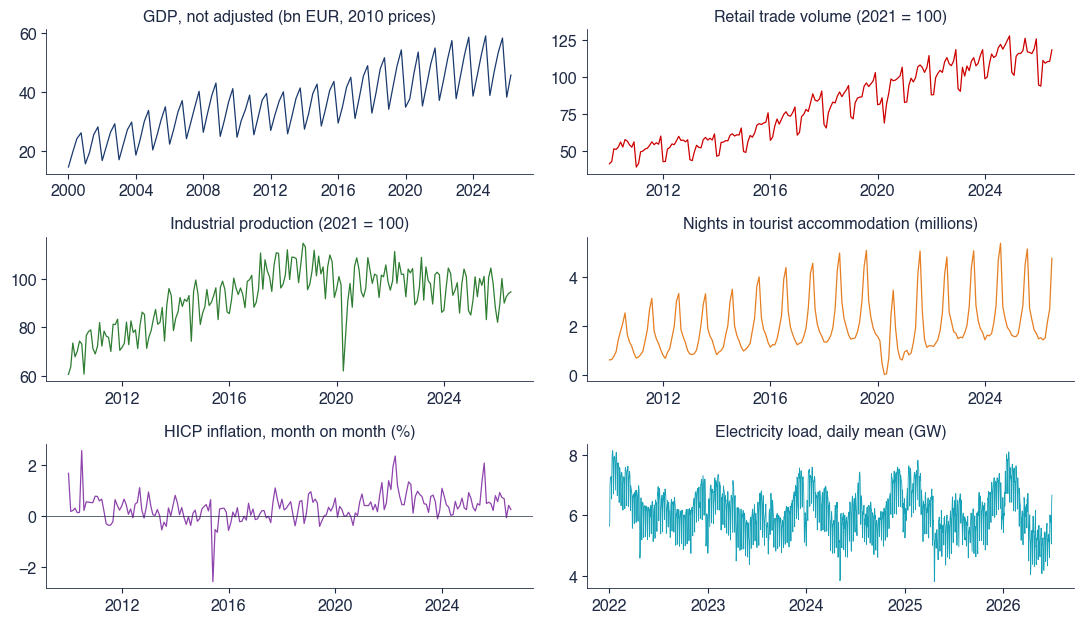

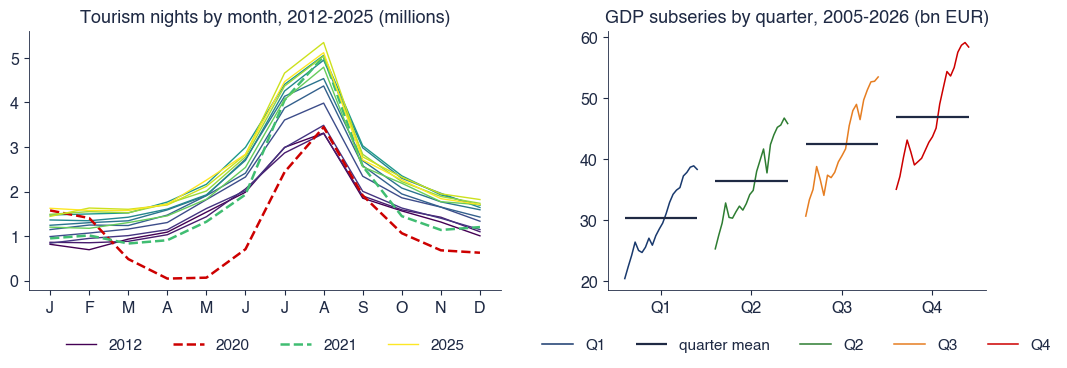

{'tour19_aug': 5.057673,
 'tour19_jan': 1.472761,
 'tour20_apr': 0.045196,
 'tour19_apr': 1.764779}

In [7]:
def airline():
    """Box and Jenkins' monthly international airline passengers (thousands), 1949-1960 (R data set via statsmodels)."""
    import statsmodels.api as sm
    d = sm.datasets.get_rdataset('AirPassengers', 'datasets').data
    return pd.Series(d['value'].values.astype(float), index=pd.date_range('1949-01-01', periods=len(d), freq='MS'),
                     name='passengers')


def fig_series(save_it=True):
    """Six Romanian series with seasonality: GDP (NSA), retail trade, industrial production, tourism nights,
    monthly HICP inflation, daily electricity load."""
    gdp = read_eurostat(*GDP_NSA).loc[GDP_START:] / 1000
    ret = read_eurostat(*RETAIL).loc['2010':]
    ipi = read_eurostat(*IPI).loc['2010':]
    tour = read_eurostat(*TOUR).loc['2010':] / 1e6
    infl = 100 * np.log(read_eurostat(*HICP)).diff().loc['2010':]
    load = load_daily()
    panels = [('GDP, not adjusted (bn EUR, 2010 prices)', gdp, st.MainBlue), ('Retail trade volume (2021 = 100)', ret, st.IDAred),
              ('Industrial production (2021 = 100)', ipi, st.Forest), ('Nights in tourist accommodation (millions)', tour, st.Orange),
              ('HICP inflation, month on month (%)', infl, st.Purple), ('Electricity load, daily mean (GW)', load, st.Teal)]
    fig, ax = plt.subplots(3, 2, figsize=(11.0, 6.4))
    for a, (t, s, c) in zip(ax.ravel(), panels):
        a.plot(s.index, s.values, color=c, lw=0.9 if len(s) < 500 else 0.6, label=t)
        a.set_title(t, fontsize=11.5)
        if 'HICP' in t:
            a.axhline(0, color=st.DarkText, lw=0.5)
        a.xaxis.set_major_locator(mdates.YearLocator(base=4 if len(s) < 500 else 1))
        a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    save('tsa_ch4_series', save_it)
    q = gdp.groupby(gdp.index.quarter).mean()
    mt = tour.loc['2015':'2019']
    mt = mt.groupby(mt.index.month).mean()
    mi = infl.loc['2010':'2019']
    mi = mi.groupby(mi.index.month).mean()
    return {'gdp_first': str(gdp.index[0].date()), 'gdp_last': str(gdp.index[-1].date()), 'gdp_T': int(len(gdp)),
            'gdp_q': q.round(4).tolist(), 'gdp_q4_q1': float(q[4] / q[1] - 1),
            'ret_last': str(ret.index[-1].date()), 'tour_last': str(tour.index[-1].date()),
            'tour_aug_jan': float(mt[8] / mt[1]), 'tour_max_m': int(mt.idxmax()), 'tour_min_m': int(mt.idxmin()),
            'infl_month_mean': mi.round(3).tolist(), 'infl_last': str(infl.index[-1].date()),
            'load_first': str(load.index[0].date()), 'load_last': str(load.index[-1].date()), 'load_T': int(len(load)),
            'load_mean': float(load.mean())}


def fig_seasonal_plot(save_it=True):
    """Seasonal plot of tourism nights (one line per year) and the quarterly subseries of GDP."""
    tour = read_eurostat(*TOUR).loc['2012':'2025'] / 1e6
    gdp = read_eurostat(*GDP_NSA).loc['2005':] / 1000
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.9), gridspec_kw={'width_ratios': [1.25, 1]})
    years = sorted(set(tour.index.year))
    cmap = plt.get_cmap('viridis')
    for i, y in enumerate(years):
        s = tour.loc[str(y)]
        special = y in (2020, 2021)
        ax[0].plot(s.index.month, s.values, color=st.IDAred if y == 2020 else cmap(i / (len(years) - 1)),
                   lw=1.8 if special else 1.0, ls='--' if special else '-', label=str(y) if y in (2012, 2020, 2021, 2025) else '_nolegend_')
    ax[0].set_xticks(range(1, 13))
    ax[0].set_xticklabels(list('JFMAMJJASOND'))
    ax[0].set_title('Tourism nights by month, 2012-2025 (millions)')
    st.legend_outside_bottom(ax[0], ncol=4, y=-0.13)
    cols = [st.MainBlue, st.Forest, st.Orange, st.IDAred]
    for q in range(1, 5):
        s = gdp[gdp.index.quarter == q]
        x = (q - 1) + np.linspace(0.1, 0.9, len(s))
        ax[1].plot(x, s.values, color=cols[q - 1], lw=1.1, label=f'Q{q}')
        ax[1].hlines(s.mean(), q - 1 + 0.1, q - 1 + 0.9, color=st.DarkText, lw=1.6, label='quarter mean' if q == 1 else '_nolegend_')
    ax[1].set_xticks([0.5, 1.5, 2.5, 3.5])
    ax[1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax[1].set_title('GDP subseries by quarter, 2005-2026 (bn EUR)')
    st.legend_outside_bottom(ax[1], ncol=5, y=-0.13)
    plt.tight_layout()
    save('tsa_ch4_seasonal_plot', save_it)
    t19 = tour.loc['2019']
    return {'tour19_aug': float(t19.iloc[7]), 'tour19_jan': float(t19.iloc[0]), 'tour20_apr': float(tour.loc['2020-04-01']),
            'tour19_apr': float(tour.loc['2019-04-01'])}


fig_series(save_it=False)
fig_seasonal_plot(save_it=False)

## 2. Seasonal differences and seasonal unit roots

- The roots of $1 - z^s$; the ACF of log GDP after $\Delta$, $\Delta_4$ and $\Delta\Delta_4$; HEGY with simulated critical values; OCSB and Canova–Hansen (pmdarima, if installed).

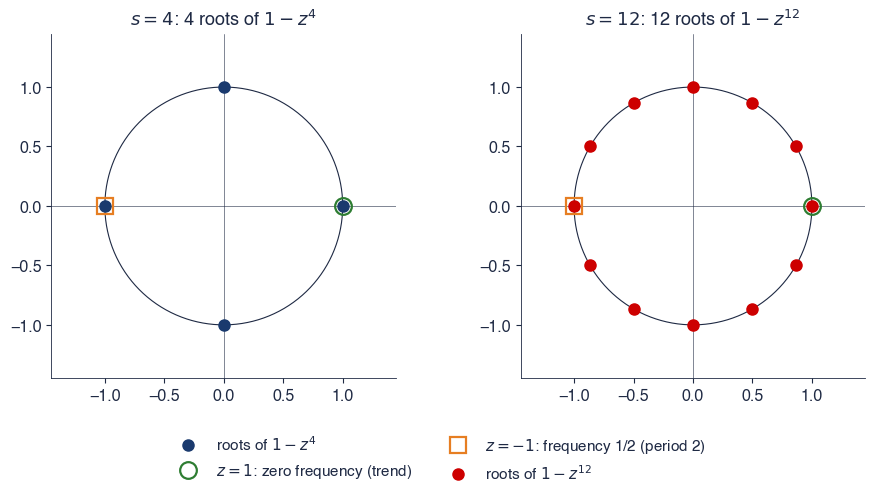

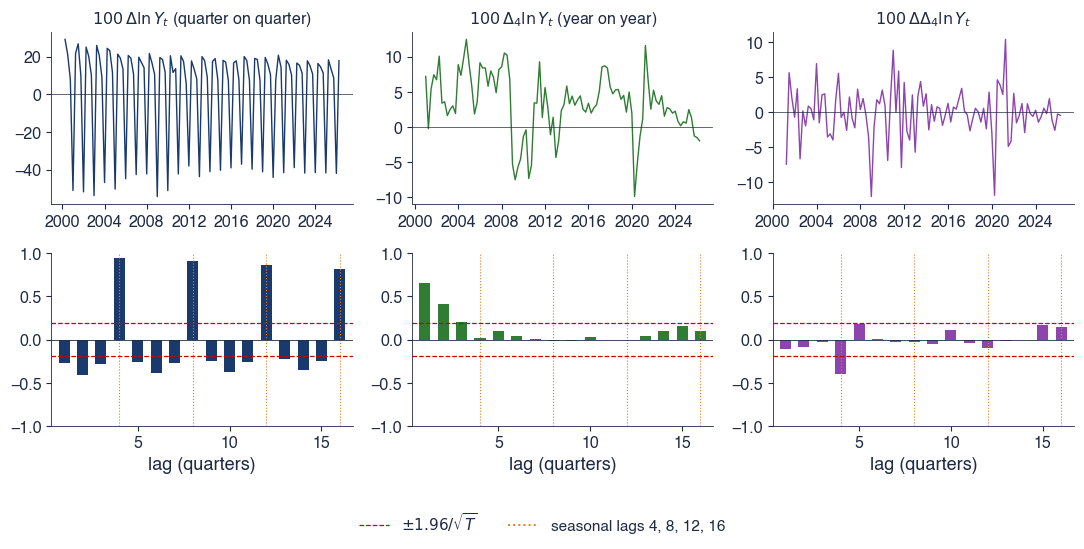

{'t1': -1.9654636105807388, 't2': -2.1899687897159312, 'F34': 6.11888778802938, 'n': 75, 'aic': -308.30203428244124} {'t1': -3.3856941900886666, 't2': -2.7746026925254053, 'F34': 6.635487209221204, 'nrep': 4000}


,series,m,ocsb,ch,d_kpss
0,GDP,4,1,0,1
1,Retail trade,12,0,0,1
2,Industrial production,12,0,0,1
3,Tourism nights,12,0,0,1
4,HICP,12,0,0,2


In [8]:
def fig_unit_circle(save_it=True):
    """The roots of 1 - z^4 and 1 - z^12 on the unit circle, with their frequencies."""
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 4.3))
    th = np.linspace(0, 2 * np.pi, 400)
    for a, s, c in [(ax[0], 4, st.MainBlue), (ax[1], 12, st.IDAred)]:
        a.plot(np.cos(th), np.sin(th), color=st.DarkText, lw=0.8)
        a.axhline(0, color=st.DarkText, lw=0.4)
        a.axvline(0, color=st.DarkText, lw=0.4)
        z = np.exp(2j * np.pi * np.arange(s) / s)
        a.plot(z.real, z.imag, 'o', ms=8, color=c, label=f'roots of $1 - z^{{{s}}}$')
        a.plot([1], [0], 'o', ms=12, mfc='none', mec=st.Forest, mew=1.6, label='$z = 1$: zero frequency (trend)')
        a.plot([-1], [0], 's', ms=12, mfc='none', mec=st.Orange, mew=1.6, label=f'$z = -1$: frequency 1/2 (period 2)')
        a.set_aspect('equal')
        a.set_xlim(-1.45, 1.45)
        a.set_ylim(-1.45, 1.45)
        a.set_title(f'$s = {s}$: {s} roots of $1 - z^{{{s}}}$')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout()
    save('tsa_ch4_unit_circle', save_it)
    return {'roots4': ['1', '-1', 'i', '-i']}


def fig_gdp_differencing(nlags=16, save_it=True):
    """Romanian log GDP (not adjusted): Delta, Delta_4 and Delta Delta_4, with their sample ACF."""
    y = eurostat_log(GDP_NSA, GDP_START)
    d1 = 100 * y.diff().dropna()
    d4 = 100 * y.diff(4).dropna()
    dd = 100 * y.diff(4).diff().dropna()
    fig, ax = plt.subplots(2, 3, figsize=(11.0, 5.0))
    out = {}
    for j, (lab, s, c) in enumerate([(r'$100\,\Delta \ln Y_t$ (quarter on quarter)', d1, st.MainBlue),
                                     (r'$100\,\Delta_4 \ln Y_t$ (year on year)', d4, st.Forest),
                                     (r'$100\,\Delta\Delta_4 \ln Y_t$', dd, st.Purple)]):
        ax[0, j].plot(s.index, s.values, color=c, lw=1.0)
        ax[0, j].axhline(0, color=st.DarkText, lw=0.5)
        ax[0, j].set_title(lab, fontsize=11.5)
        r = sample_acf(s.values, nlags)
        acf_bars(ax[1, j], r, len(s), color=c, mark=[4, 8, 12, 16])
        ax[1, j].set_ylim(-1, 1)
        ax[1, j].set_xlabel('lag (quarters)')
        out[['d1', 'd4', 'dd'][j]] = {'r': r[:8].round(4).tolist(), 'T': int(len(s)), 'sd': float(s.std())}
    ax[1, 0].plot([], [], color=st.Orange, ls=':', label='seasonal lags 4, 8, 12, 16')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch4_gdp_diff', save_it)
    out['r4_d1'] = out['d1']['r'][3]
    out['r8_d1'] = out['d1']['r'][7]
    return out


def hegy_stats(y, k=0, trend=True):
    """HEGY regression for quarterly data (Hylleberg et al., 1990):
    D4 y_t = pi1 y1_{t-1} + pi2 y2_{t-1} + pi3 y3_{t-2} + pi4 y3_{t-1} + const + 3 seasonal dummies (+ trend)
             + sum_{j=1..k} a_j D4 y_{t-j} + e_t,
    y1 = (1 + L + L^2 + L^3) y, y2 = -(1 - L + L^2 - L^3) y, y3 = -(1 - L^2) y.
    Returns t(pi1), t(pi2), F(pi3 = pi4 = 0) and the number of observations."""
    y = np.asarray(y, float)
    n = len(y)
    L = lambda x, j: np.r_[np.full(j, np.nan), x[:n - j]]
    y1 = y + L(y, 1) + L(y, 2) + L(y, 3)
    y2 = -(y - L(y, 1) + L(y, 2) - L(y, 3))
    y3 = -(y - L(y, 2))
    d4 = y - L(y, 4)
    X = [L(y1, 1), L(y2, 1), L(y3, 2), L(y3, 1), np.ones(n)]
    q = np.arange(n) % 4
    X += [(q == j).astype(float) for j in (1, 2, 3)]
    if trend:
        X.append(np.arange(n, dtype=float))
    X += [L(d4, j) for j in range(1, k + 1)]
    X = np.column_stack(X)
    ok = ~np.isnan(X).any(axis=1) & ~np.isnan(d4)
    r = OLS(d4[ok], X[ok]).fit()
    F = float(r.f_test(np.eye(X.shape[1])[[2, 3]]).fvalue)
    return {'t1': float(r.tvalues[0]), 't2': float(r.tvalues[1]), 'F34': F, 'n': int(ok.sum()), 'aic': float(r.aic)}


def hegy_critical(n, nrep=4000, trend=True, seed=SEED):
    """5% critical values of the HEGY statistics by simulation under the null D4 y_t = e_t (seasonal random walk),
    with the same sample size and deterministic terms."""
    rng = np.random.default_rng(seed)
    res = []
    for _ in range(nrep):
        e = rng.normal(size=n + 4)
        y = np.zeros(n + 4)
        for t in range(4, n + 4):
            y[t] = y[t - 4] + e[t]
        h = hegy_stats(y, 0, trend)
        res.append((h['t1'], h['t2'], h['F34']))
    res = np.array(res)
    return {'t1': float(np.quantile(res[:, 0], 0.05)), 't2': float(np.quantile(res[:, 1], 0.05)),
            'F34': float(np.quantile(res[:, 2], 0.95)), 'nrep': nrep}


def seasonal_tests(save_csv=True):
    """HEGY on Romanian log GDP (not adjusted, 2000-2019); OCSB and Canova-Hansen decisions (pmdarima nsdiffs) and
    the KPSS-based number of regular differences for five series, sample 2005-2019 (before the pandemic)."""
    y = eurostat_log(GDP_NSA, '2000-01-01').loc[:'2019-10-01']
    ks = {k: hegy_stats(y.values, k)['aic'] for k in range(0, 5)}
    k = int(min(ks, key=ks.get))
    h = hegy_stats(y.values, k)
    cv = hegy_critical(h['n'])
    out = {'hegy': h, 'hegy_k': k, 'hegy_cv': cv, 'hegy_first': str(y.index[0].date()), 'hegy_last': str(y.index[-1].date())}
    rows = []
    if have('pmdarima'):
        import pmdarima as pm
        for name, key, m in [('GDP', GDP_NSA, 4), ('Retail trade', RETAIL, 12), ('Industrial production', IPI, 12),
                             ('Tourism nights', TOUR, 12), ('HICP', HICP, 12)]:
            x = eurostat_log(key, '2005-01-01').loc[:'2019-12-31']
            rows.append({'series': name, 'm': m, 'ocsb': int(pm.arima.nsdiffs(x.values, m=m, test='ocsb')),
                         'ch': int(pm.arima.nsdiffs(x.values, m=m, test='ch')),
                         'd_kpss': int(pm.arima.ndiffs(x.values, test='kpss'))})
    out['table'] = rows
    if save_csv and rows:
        pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch4_seasonal_tests.csv'), index=False)
    return out


fig_unit_circle(save_it=False)
fig_gdp_differencing(save_it=False)
tests = seasonal_tests(save_csv=False)
print(tests['hegy'], tests['hegy_cv'])
pd.DataFrame(tests['table'])

## 3. SARIMA: theoretical ACF and PACF

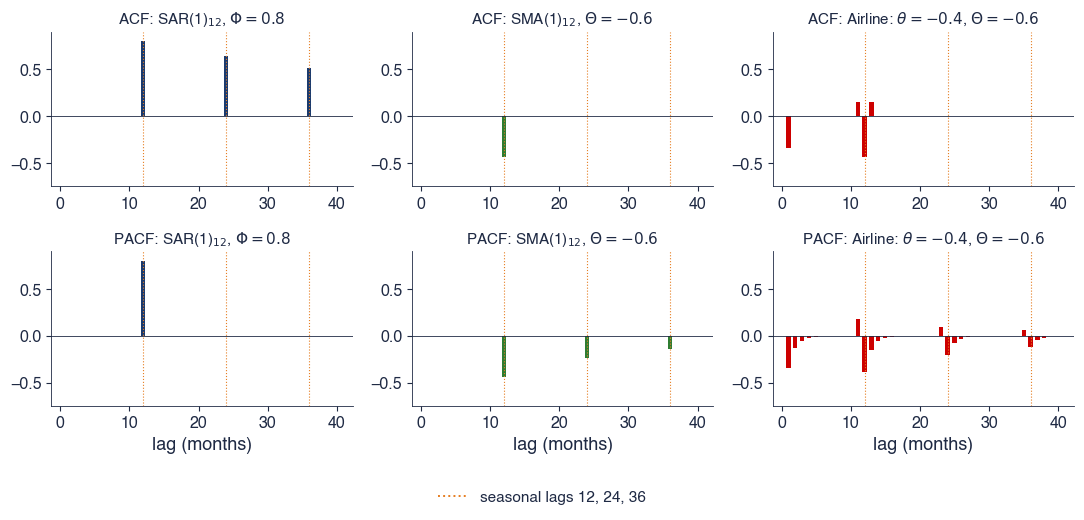

In [9]:
def fig_theory_acf(nlags=40, save_it=True):
    """Theoretical ACF and PACF of SAR(1)_12 (Phi = 0.8), SMA(1)_12 (Theta = -0.6) and the airline model
    (theta = -0.4, Theta = -0.6) for the stationary part w_t = Delta Delta_12 y_t."""
    models = [('SAR(1)$_{12}$, $\\Phi = 0.8$', dict(Phi=[0.8]), st.MainBlue),
              ('SMA(1)$_{12}$, $\\Theta = -0.6$', dict(Theta=[-0.6]), st.Forest),
              ('Airline: $\\theta = -0.4$, $\\Theta = -0.6$', dict(theta=[-0.4], Theta=[-0.6]), st.IDAred)]
    fig, ax = plt.subplots(2, 3, figsize=(11.0, 4.8))
    out = {}
    for j, (t, kw, c) in enumerate(models):
        p = sarma_process(s=12, **kw)
        r = p.acf(nlags + 1)[1:]
        pa = p.pacf(nlags + 1)[1:]
        for i, (v, lab) in enumerate([(r, 'ACF'), (pa, 'PACF')]):
            ax[i, j].bar(np.arange(1, nlags + 1), v, width=0.6, color=c)
            ax[i, j].axhline(0, color=st.DarkText, lw=0.6)
            for m in (12, 24, 36):
                ax[i, j].axvline(m, color=st.Orange, lw=0.8, ls=':')
            ax[i, j].set_ylim(-0.75, 0.9)
            ax[i, j].set_title(f'{lab}: {t}', fontsize=11)
        ax[1, j].set_xlabel('lag (months)')
        out[['sar', 'sma', 'airline'][j]] = {'acf': r[:37].round(4).tolist(), 'pacf': pa[:37].round(4).tolist()}
    ax[1, 0].plot([], [], color=st.Orange, ls=':', label='seasonal lags 12, 24, 36')
    st.fig_legend_bottom(fig, ncol=1, y=-0.01)
    plt.tight_layout()
    save('tsa_ch4_theory_acf', save_it)
    return out


th = fig_theory_acf(save_it=False)

## 4. The airline model

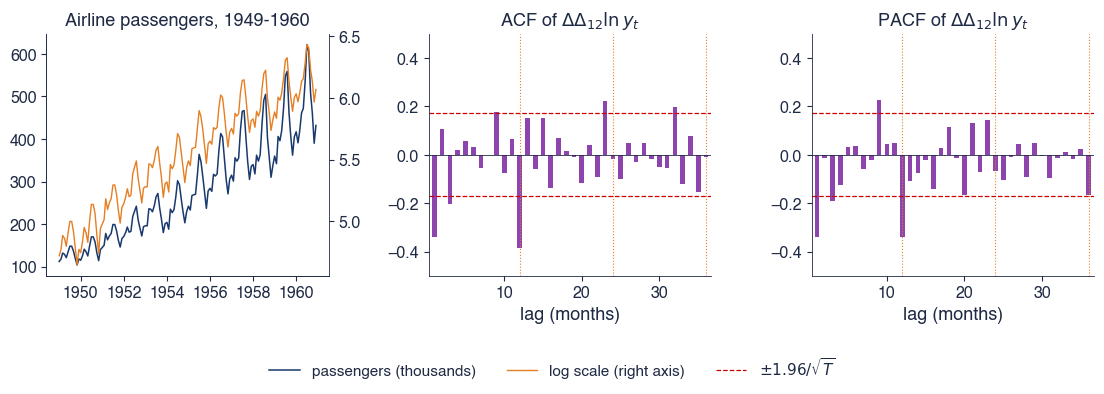

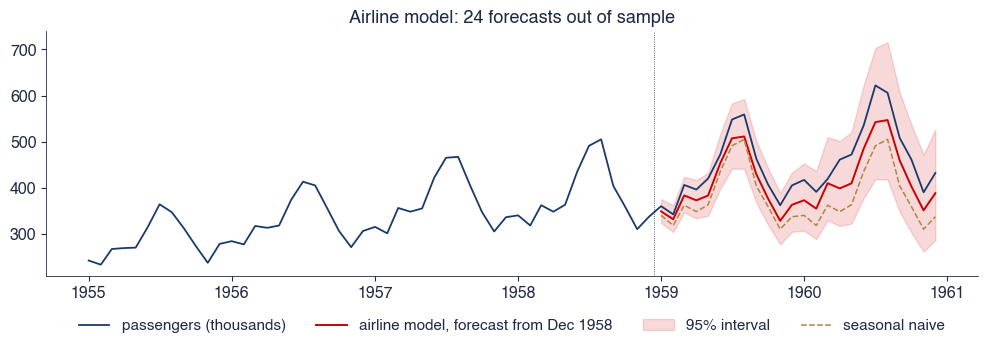

{'theta': -0.3424635954467906,
 'Theta': -0.5405504037373503,
 'theta_se': 0.08729455854229616,
 'Theta_se': 0.10483329232401903,
 'sigma': 0.037445882096119466,
 'full_theta': -0.4018318870862551,
 'full_Theta': -0.5570160839939424,
 'full_theta_se': 0.07301736204717865,
 'full_Theta_se': 0.09629300663111434,
 'full_sigma': 0.03671331018875414,
 'lb24': {'lb': 23.620074375497584, 'df': 22, 'lb_p': 0.36745463036734793},
 'mape_sarima': 8.515605211970433,
 'mape_snaive': 15.52335516242037,
 'f_last': 388.15217745758156,
 'lo_last': 286.4616626125317,
 'hi_last': 525.9416268516447,
 'act_last': 432.00000000000017,
 'width_1': 51.21345748858067,
 'width_24': 239.47996423911303}

In [10]:
def fig_airline(nlags=36, save_it=True):
    """Airline passengers: the series, its log, and the ACF and PACF of w_t = Delta Delta_12 ln y_t."""
    y = airline()
    ly = np.log(y)
    w = ly.diff(12).diff().dropna()
    fig, ax = plt.subplots(1, 3, figsize=(11.2, 3.5))
    ax[0].plot(y.index, y.values, color=st.MainBlue, lw=1.1, label='passengers (thousands)')
    a2 = ax[0].twinx()
    a2.plot(ly.index, ly.values, color=st.Orange, lw=1.0, label='log scale (right axis)')
    a2.spines['right'].set_visible(True)
    ax[0].set_title('Airline passengers, 1949-1960')
    acf_bars(ax[1], sample_acf(w, nlags), len(w), color=st.Purple, mark=[12, 24, 36])
    acf_bars(ax[2], sample_pacf(w, nlags), len(w), color=st.Purple, band=False, mark=[12, 24, 36])
    b = 1.96 / np.sqrt(len(w))
    ax[2].axhline(b, color=BAND_COL, ls='--', lw=0.9)
    ax[2].axhline(-b, color=BAND_COL, ls='--', lw=0.9)
    ax[1].set_title(r'ACF of $\Delta\Delta_{12}\ln y_t$')
    ax[2].set_title(r'PACF of $\Delta\Delta_{12}\ln y_t$')
    for a in ax[1:]:
        a.set_xlabel('lag (months)')
        a.set_ylim(-0.5, 0.5)
    h1, l1 = ax[0].get_legend_handles_labels()
    h2, l2 = a2.get_legend_handles_labels()
    h3, l3 = ax[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h1 + h2 + h3, l1 + l2 + l3, ncol=3, y=0.0)
    plt.tight_layout()
    save('tsa_ch4_airline', save_it)
    r = sample_acf(w, 24)
    return {'T': int(len(y)), 'Tw': int(len(w)), 'r1': float(r[0]), 'r12': float(r[11]), 'r11': float(r[10]),
            'r13': float(r[12]), 'r3': float(r[2]), 'band': float(1.96 / np.sqrt(len(w)))}


def fig_airline_forecast(save_it=True):
    """The airline model SARIMA(0,1,1)(0,1,1)_12 for ln y on 1949-1958, forecasts for 1959-1960 with 95% intervals,
    compared with the seasonal naive forecast; full-sample estimates."""
    y = airline()
    ly = np.log(y)
    tr, te = ly.loc[:'1958-12-01'], ly.loc['1959-01-01':]
    m = fit_sarima(tr, (0, 1, 1), (0, 1, 1, 12))
    fc = m.get_forecast(len(te))
    f = np.exp(fc.predicted_mean)
    ci = np.exp(fc.conf_int(alpha=0.05))
    sn = np.exp(np.r_[tr.values[-12:], tr.values[-12:]])
    full = fit_sarima(ly, (0, 1, 1), (0, 1, 1, 12))
    e = full.resid[13:]
    fig, ax = plt.subplots(figsize=(10.4, 3.7))
    ax.plot(y.loc['1955':].index, y.loc['1955':].values, color=st.MainBlue, lw=1.3, label='passengers (thousands)')
    ax.plot(te.index, f, color=st.IDAred, lw=1.4, label='airline model, forecast from Dec 1958')
    ax.fill_between(te.index, ci[:, 0], ci[:, 1], color=st.IDAred, alpha=0.15, label='95% interval')
    ax.plot(te.index, sn, color=st.Amber, lw=1.1, ls='--', label='seasonal naive')
    ax.axvline(pd.Timestamp('1958-12-15'), color=st.DarkText, lw=0.6, ls=':')
    ax.set_title('Airline model: 24 forecasts out of sample')
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    plt.tight_layout()
    save('tsa_ch4_airline_fc', save_it)
    act = np.exp(te.values)
    mape = lambda a, b: float(100 * np.mean(np.abs(a - b) / a))
    return {'theta': float(m.params[0]), 'Theta': float(m.params[1]), 'theta_se': float(m.bse[0]), 'Theta_se': float(m.bse[1]),
            'sigma': float(np.sqrt(m.params[2])), 'full_theta': float(full.params[0]), 'full_Theta': float(full.params[1]),
            'full_theta_se': float(full.bse[0]), 'full_Theta_se': float(full.bse[1]), 'full_sigma': float(np.sqrt(full.params[2])),
            'lb24': ljung_box(e, 24, 22), 'mape_sarima': mape(act, f), 'mape_snaive': mape(act, sn),
            'f_last': float(f[-1]), 'lo_last': float(ci[-1, 0]), 'hi_last': float(ci[-1, 1]), 'act_last': float(act[-1]),
            'width_1': float(ci[0, 1] - ci[0, 0]), 'width_24': float(ci[-1, 1] - ci[-1, 0])}


fig_airline(save_it=False)
fig_airline_forecast(save_it=False)

## 5. Romanian GDP (not adjusted): SARIMA

In [11]:
def gdp_models(save_csv=True):
    """SARIMA(p,1,q)(P,1,Q)_4 models of 100 ln GDP (not adjusted), 2000Q1 onwards: AICc, BIC, Ljung-Box (8 lags)."""
    y = 100 * eurostat_log(GDP_NSA, GDP_START)
    rows = []
    n = len(y) - 5
    for o, so in GDP_GRID:
        r = fit_sarima(y, o, so + (4,))
        k = len(r.params) - 1
        lb = ljung_box(r.resid[5:], 8, 8 - k)
        rows.append({'model': f'({o[0]},1,{o[2]})({so[0]},1,{so[2]})4', 'k': k, 'loglik': float(r.llf), 'aicc': aicc(r, n),
                     'bic': float(r.bic), 'lb8_p': lb['lb_p'], 'sigma': float(np.sqrt(r.params[-1])),
                     'params': {nm: float(v) for nm, v in zip(r.param_names, r.params)},
                     'se': {nm: float(v) for nm, v in zip(r.param_names, r.bse)}})
    t = pd.DataFrame(rows)
    if save_csv:
        t.drop(columns=['params', 'se']).round(3).to_csv(os.path.join(HERE, 'ch4_gdp_models.csv'), index=False)
    best_aicc = t.loc[t['aicc'].idxmin(), 'model']
    best_bic = t.loc[t['bic'].idxmin(), 'model']
    return {'rows': rows, 'best_aicc': best_aicc, 'best_bic': best_bic, 'T': int(len(y)), 'first': str(y.index[0].date()),
            'last': str(y.index[-1].date())}


def parse_model(m):
    """'(0,1,1)(0,1,1)4' -> ((0, 1, 1), (0, 1, 1))."""
    a, b = m.split(')(')
    o = tuple(int(x) for x in a.strip('(').split(','))
    so = tuple(int(x) for x in b.split(')')[0].split(','))
    return o, so


def fig_gdp_diag(order=(0, 1, 1), sorder=(0, 1, 1), nlags=16, save_it=True):
    """Residual diagnostics of the GDP SARIMA: residuals, ACF, histogram with the Normal density."""
    y = 100 * eurostat_log(GDP_NSA, GDP_START)
    r = fit_sarima(y, order, sorder + (4,))
    e = pd.Series(r.resid[5:], index=y.index[5:])
    k = sum(order[::2]) + sum(sorder[::2])
    fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.4))
    ax[0].plot(e.index, e.values, color=st.MainBlue, lw=1.0)
    ax[0].axhline(0, color=st.DarkText, lw=0.5)
    ax[0].set_title('Residuals (%)')
    acf_bars(ax[1], sample_acf(e.values, nlags), len(e), color=st.MainBlue, mark=[4, 8, 12, 16])
    ax[1].set_ylim(-0.6, 0.6)
    ax[1].set_title('ACF of the residuals')
    ax[1].set_xlabel('lag (quarters)')
    ax[2].hist(e.values, bins=22, density=True, color=st.Teal, alpha=0.8, label='residuals')
    g = np.linspace(e.min() - 1, e.max() + 1, 200)
    ax[2].plot(g, stats.norm.pdf(g, e.mean(), e.std()), color=st.IDAred, lw=1.4, label='Normal density')
    ax[2].set_title('Distribution of the residuals')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout()
    save('tsa_ch4_gdp_diag', save_it)
    jb = stats.jarque_bera(e.values)
    i = int(np.argmax(np.abs(e.values)))
    ex = e.drop(e.loc['2020'].index)
    return {'lb8': ljung_box(e.values, 8, 8 - k), 'lb12': ljung_box(e.values, 12, 12 - k), 'jb': float(jb.statistic),
            'jb_p': float(jb.pvalue), 'out_d': str(e.index[i].date()), 'out_v': float(e.iloc[i]), 'sd': float(e.std()),
            'out_z': float(e.iloc[i] / e.std()), 'lb8_ex2020': ljung_box(ex.values, 8, 8 - k),
            'jb_ex2020': float(stats.jarque_bera(ex.values).statistic)}


def fig_gdp_forecast(order=(0, 1, 1), sorder=(0, 1, 1), H=8, save_it=True):
    """Forecasts of GDP (not adjusted) 8 quarters ahead with 80% and 95% intervals, back-transformed from 100 ln Y,
    and the implied year-on-year growth."""
    y = 100 * eurostat_log(GDP_NSA, GDP_START)
    r = fit_sarima(y, order, sorder + (4,))
    fc = r.get_forecast(H)
    idx = pd.date_range(y.index[-1] + pd.offsets.QuarterBegin(startingMonth=1), periods=H, freq='QS')
    f = np.exp(fc.predicted_mean / 100) / 1000
    c95 = np.exp(fc.conf_int(alpha=0.05) / 100) / 1000
    c80 = np.exp(fc.conf_int(alpha=0.20) / 100) / 1000
    lev = np.exp(y / 100) / 1000
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.6), gridspec_kw={'width_ratios': [1.6, 1]})
    ax[0].plot(lev.loc['2016':].index, lev.loc['2016':].values, color=st.MainBlue, lw=1.3, label='GDP, not adjusted (bn EUR)')
    ax[0].plot(idx, f, color=st.IDAred, lw=1.4, marker='o', ms=3, label='SARIMA forecast')
    ax[0].fill_between(idx, c95[:, 0], c95[:, 1], color=st.IDAred, alpha=0.12, label='95% interval')
    ax[0].fill_between(idx, c80[:, 0], c80[:, 1], color=st.IDAred, alpha=0.22, label='80% interval')
    ax[0].set_title('Romanian GDP: SARIMA forecasts, 8 quarters')
    st.legend_outside_bottom(ax[0], ncol=2, y=-0.13)
    yy = np.r_[y.values, fc.predicted_mean]
    g = (yy[4:] - yy[:-4])
    gi = pd.date_range(y.index[4], periods=len(g), freq='QS')
    ax[1].bar(gi[-16:-H], g[-16:-H], width=60, color=st.MainBlue, label='observed')
    ax[1].bar(gi[-H:], g[-H:], width=60, color=st.IDAred, label='implied by the forecast')
    ax[1].axhline(0, color=st.DarkText, lw=0.5)
    ax[1].set_title('Year-on-year growth, 100 $\\Delta_4 \\ln Y$ (%)')
    ax[1].xaxis.set_major_locator(mdates.YearLocator())
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.13)
    plt.tight_layout()
    save('tsa_ch4_gdp_fc', save_it)
    return {'f': f.tolist(), 'lo95': c95[:, 0].tolist(), 'hi95': c95[:, 1].tolist(), 'first_f': str(idx[0].date()),
            'last_f': str(idx[-1].date()), 'g_f': g[-H:].tolist(), 'last_obs': float(lev.iloc[-1]),
            'last_obs_d': str(lev.index[-1].date()), 'params': dict(zip(r.param_names, map(float, r.params))),
            'se': dict(zip(r.param_names, map(float, r.bse))), 'sigma': float(np.sqrt(r.params[-1])),
            'order': [list(order), list(sorder)]}


T = gdp_models(save_csv=False)
print('AICc:', T['best_aicc'], ' BIC:', T['best_bic'])
pd.DataFrame(T['rows'])[['model', 'k', 'aicc', 'bic', 'lb8_p', 'sigma']].round(3)

AICc: (1,1,1)(0,1,1)4  BIC: (0,1,0)(0,1,1)4


,model,k,aicc,bic,lb8_p,sigma
0,"(0,1,1)(0,1,1)4",2,520.051,527.649,0.157,3.053
1,"(1,1,0)(0,1,1)4",2,520.682,528.280,0.156,3.064
2,"(1,1,1)(0,1,1)4",3,518.329,528.373,0.467,2.984
3,"(0,1,2)(0,1,1)4",3,518.765,528.809,0.575,2.998
4,"(2,1,0)(0,1,1)4",3,520.126,530.170,0.382,3.021
5,"(0,1,1)(1,1,0)4",2,529.875,537.473,0.003,3.221
6,"(1,1,0)(1,1,0)4",2,530.208,537.806,0.004,3.226
7,"(0,1,1)(1,1,1)4",3,522.158,532.202,0.118,3.052
8,"(0,1,0)(0,1,1)4",1,519.682,524.790,0.286,3.081
9,"(0,1,1)(0,1,0)4",1,545.136,550.244,0.005,3.523


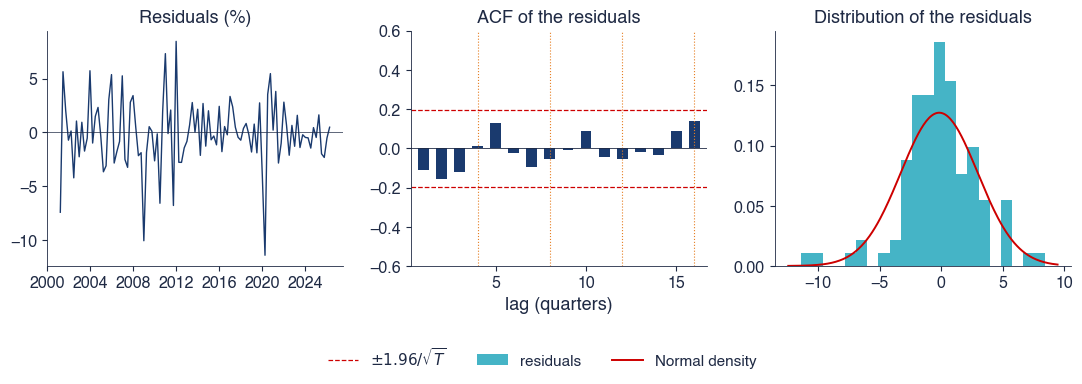

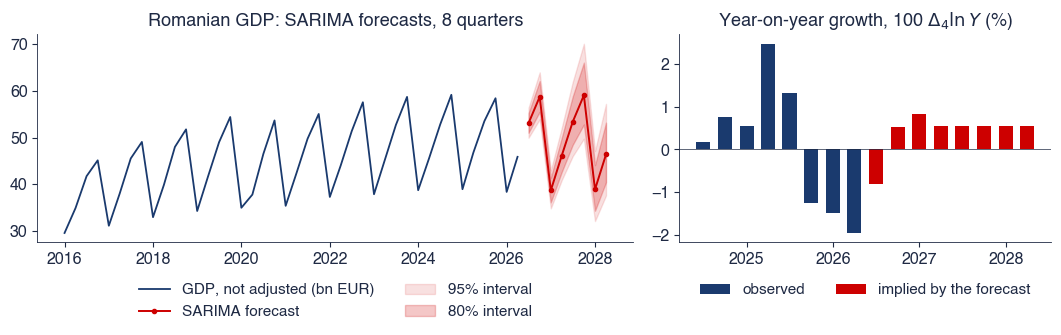

{'lb8': {'lb': 8.553385581565179, 'df': 7, 'lb_p': 0.28632999097811956},
 'lb12': {'lb': 10.052861991990326, 'df': 11, 'lb_p': 0.5256385411937505},
 'jb': 21.969604783217598,
 'jb_p': 1.6957465279848968e-05,
 'out_d': '2020-04-01',
 'out_v': -11.425590397500173,
 'sd': 3.1345562090622705,
 'out_z': -3.6450424351835875,
 'lb8_ex2020': {'lb': 8.892999764650284, 'df': 7, 'lb_p': 0.2604298271551359},
 'jb_ex2020': 13.385837616681343}

In [12]:
o, so = parse_model(T['best_bic'])
diag = fig_gdp_diag(o, so, save_it=False)
fc = fig_gdp_forecast(o, so, save_it=False)
diag

## 6. Seasonal adjustment: Eurostat NSA and SCA series

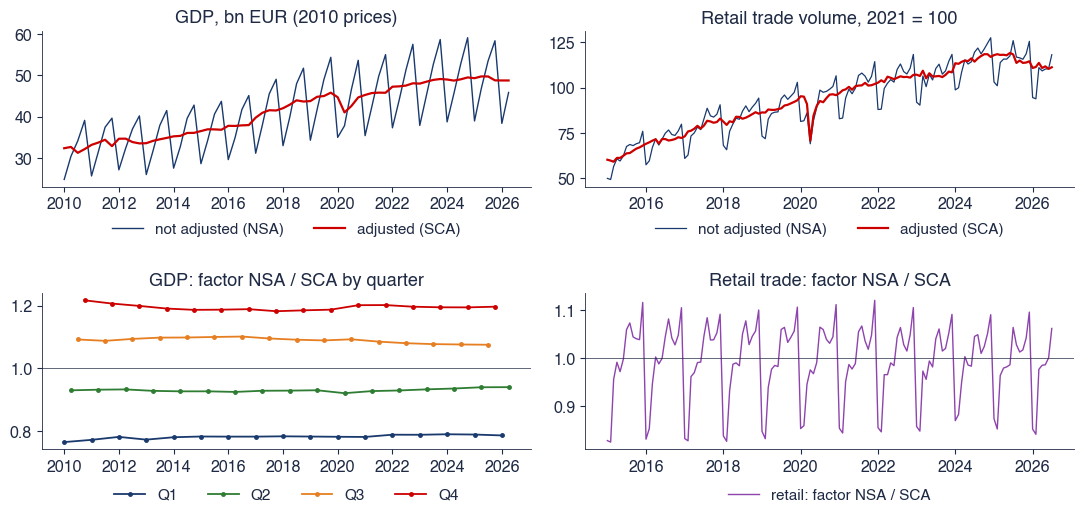

{'fq': [0.7829, 0.9282, 1.0958, 1.1865],
 'qoq_nsa': [-41.83, 18.34, 13.46, 8.77, -42.07, 17.88],
 'qoq_sca': [-0.36, 0.85, -0.01, -1.92, -0.06, 0.0],
 'qoq_dates': ['2025-01-01',
  '2025-04-01',
  '2025-07-01',
  '2025-10-01',
  '2026-01-01',
  '2026-04-01'],
 'f_dec': 1.1009646948640173,
 'f_jan': 0.8379658209030811,
 'sum_nsa_2024': 196.36720000000003,
 'sum_sca_2024': 196.3671}

In [13]:
def fig_sa_nsa(save_it=True):
    """Eurostat seasonally and calendar adjusted (SCA) and unadjusted (NSA) series: GDP and retail trade; the implied
    seasonal-calendar factors NSA/SCA."""
    g, gs = read_eurostat(*GDP_NSA).loc['2010':] / 1000, read_eurostat(*GDP_SCA).loc['2010':] / 1000
    r, rs = read_eurostat(*RETAIL).loc['2015':], read_eurostat(*RETAIL_SCA).loc['2015':]
    fg, fr = (g / gs).dropna(), (r / rs).dropna()
    fig, ax = plt.subplots(2, 2, figsize=(11.0, 5.4))
    ax[0, 0].plot(g.index, g.values, color=st.MainBlue, lw=1.0, label='not adjusted (NSA)')
    ax[0, 0].plot(gs.index, gs.values, color=st.IDAred, lw=1.6, label='adjusted (SCA)')
    ax[0, 0].set_title('GDP, bn EUR (2010 prices)')
    st.legend_outside_bottom(ax[0, 0], ncol=2, y=-0.14)
    ax[0, 1].plot(r.index, r.values, color=st.MainBlue, lw=0.9, label='not adjusted (NSA)')
    ax[0, 1].plot(rs.index, rs.values, color=st.IDAred, lw=1.6, label='adjusted (SCA)')
    st.legend_outside_bottom(ax[0, 1], ncol=2, y=-0.14)
    ax[0, 1].set_title('Retail trade volume, 2021 = 100')
    cols = [st.MainBlue, st.Forest, st.Orange, st.IDAred]
    for q in range(1, 5):
        s = fg[fg.index.quarter == q]
        ax[1, 0].plot(s.index, s.values, color=cols[q - 1], lw=1.3, marker='o', ms=2.5, label=f'Q{q}')
    ax[1, 0].axhline(1, color=st.DarkText, lw=0.5)
    ax[1, 0].set_title('GDP: factor NSA / SCA by quarter')
    st.legend_outside_bottom(ax[1, 0], ncol=4, y=-0.16)
    ax[1, 1].plot(fr.index, fr.values, color=st.Purple, lw=1.0, label='retail: factor NSA / SCA')
    ax[1, 1].axhline(1, color=st.DarkText, lw=0.5)
    ax[1, 1].set_title('Retail trade: factor NSA / SCA')
    st.legend_outside_bottom(ax[1, 1], ncol=1, y=-0.16)
    plt.tight_layout(h_pad=1.5)
    save('tsa_ch4_sa_nsa', save_it)
    fq = fg.loc['2015':'2019'].groupby(fg.loc['2015':'2019'].index.quarter).mean()
    gr_nsa = 100 * np.log(g).diff().loc['2025':]
    gr_sca = 100 * np.log(gs).diff().loc['2025':]
    fm = fr.loc['2016':'2019']
    fm = fm.groupby(fm.index.month).mean()
    return {'fq': fq.round(4).tolist(), 'qoq_nsa': gr_nsa.round(2).tolist(), 'qoq_sca': gr_sca.round(2).tolist(),
            'qoq_dates': [str(d.date()) for d in gr_nsa.index], 'f_dec': float(fm[12]), 'f_jan': float(fm[1]),
            'sum_nsa_2024': float(g.loc['2024'].sum()), 'sum_sca_2024': float(gs.loc['2024'].sum())}


fig_sa_nsa(save_it=False)

## 7. Fourier terms and calendar effects (Orthodox Easter, working days)

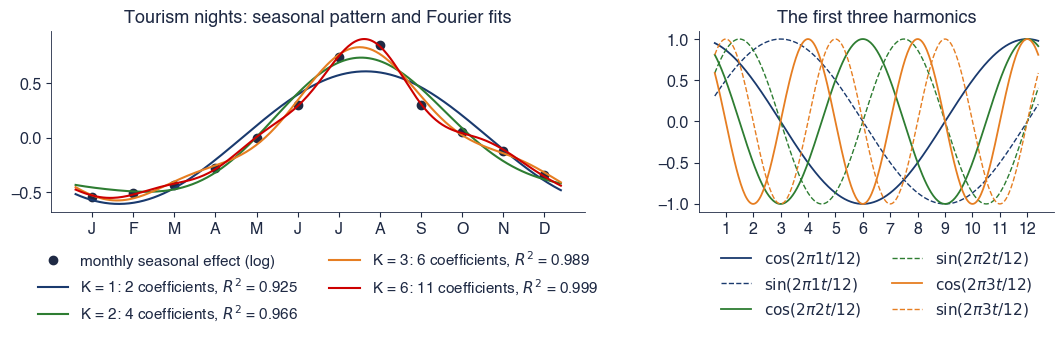

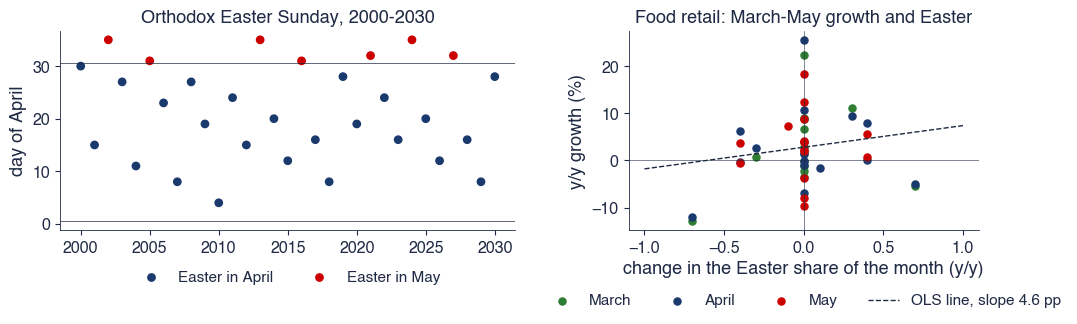

,food,food se,total,total se
easter,0.0595,0.0225,0.0076,0.0188
wd,0.0059,0.0017,0.0102,0.0015
ao_2020_04,-0.1465,0.0154,-0.2746,0.0199
ao_2020_05,-0.0090,0.0135,-0.0908,0.0209
theta,-0.3612,0.0656,-0.3940,0.0640
Theta,-0.5696,0.0584,-0.6060,0.0710
sigma2,0.0008,0.0001,0.0006,0.0001


In [14]:
def fig_fourier(save_it=True):
    """Fourier approximation of the monthly seasonal pattern of log tourism nights (2012-2019): K = 1, 2, 3 and 6
    harmonics, R^2 of each, and the number of coefficients."""
    x = eurostat_log(TOUR, '2012-01-01').loc[:'2019-12-01']
    z = (x - x.rolling(13, center=True).mean()).dropna()
    pat = z.groupby(z.index.month).mean()
    pat = pat - pat.mean()
    t = np.arange(1, 13)
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.7), gridspec_kw={'width_ratios': [1.5, 1]})
    ax[0].plot(t, pat.values, 'o', color=st.DarkText, ms=6, label='monthly seasonal effect (log)')
    tt = np.linspace(0.6, 12.4, 300)
    out = {}
    for K, c in [(1, st.MainBlue), (2, st.Forest), (3, st.Orange), (6, st.IDAred)]:
        X = fourier(t, 12, K).values
        if K == 6:
            X = X[:, :-1]                 # sin(pi t) = 0 at integer t: 11 regressors
        b = np.linalg.lstsq(X, pat.values, rcond=None)[0]
        Xg = fourier(tt, 12, K).values
        Xg = Xg[:, :-1] if K == 6 else Xg
        fit = X @ b
        r2 = 1 - np.sum((pat.values - fit) ** 2) / np.sum(pat.values ** 2)
        ax[0].plot(tt, Xg @ b, color=c, lw=1.5, label=f'K = {K}: {X.shape[1]} coefficients, $R^2$ = {r2:.3f}')
        out[f'K{K}'] = {'r2': float(r2), 'ncoef': int(X.shape[1])}
    ax[0].set_xticks(range(1, 13))
    ax[0].set_xticklabels(list('JFMAMJJASOND'))
    ax[0].set_title('Tourism nights: seasonal pattern and Fourier fits')
    st.legend_outside_bottom(ax[0], ncol=2, y=-0.13)
    for k, c in [(1, st.MainBlue), (2, st.Forest), (3, st.Orange)]:
        ax[1].plot(tt, np.cos(2 * np.pi * k * tt / 12), color=c, lw=1.3, label=f'$\\cos(2\\pi {k} t/12)$')
        ax[1].plot(tt, np.sin(2 * np.pi * k * tt / 12), color=c, lw=1.0, ls='--', label=f'$\\sin(2\\pi {k} t/12)$')
    ax[1].set_title('The first three harmonics')
    ax[1].set_xticks(range(1, 13))
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.13)
    plt.tight_layout()
    save('tsa_ch4_fourier', save_it)
    out['pat'] = pat.round(4).tolist()
    return out


def easter_regression(key=FOOD, start='2010-01-01', w=10):
    """Regression with SARIMA(0,1,1)(0,1,1)_12 errors for ln(retail volume): Orthodox Easter share (w days),
    working days, additive outliers in April and May 2020 (lockdown)."""
    y = eurostat_log(key, start)
    X = pd.DataFrame({'easter': easter_share(y.index, w), 'wd': working_days(y.index),
                      'ao_2020_04': (y.index == pd.Timestamp('2020-04-01')).astype(float),
                      'ao_2020_05': (y.index == pd.Timestamp('2020-05-01')).astype(float)}, index=y.index)
    r = fit_sarima(y, (0, 1, 1), (0, 1, 1, 12), exog=X.values)
    nm = list(X.columns) + ['theta', 'Theta', 'sigma2']
    return {'params': dict(zip(nm, map(float, r.params))), 'se': dict(zip(nm, map(float, r.bse))),
            'T': int(len(y)), 'first': str(y.index[0].date()), 'last': str(y.index[-1].date()), 'aic': float(r.aic),
            'X': X}


def fig_easter(save_it=True):
    """Orthodox Easter dates and the Easter effect in Romanian retail trade: food retail and total retail."""
    food = easter_regression(FOOD)
    tot = easter_regression(RETAIL)
    yrs = np.arange(2000, 2031)
    ed = [pd.Timestamp(easter(y, EASTER_ORTHODOX)) for y in yrs]
    doy = [d.dayofyear - pd.Timestamp(d.year, 3, 31).dayofyear for d in ed]   # days after 31 March
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.6), gridspec_kw={'width_ratios': [1.3, 1]})
    col = [st.IDAred if d.month == 5 else (st.Forest if d.month == 3 else st.MainBlue) for d in ed]
    ax[0].scatter(yrs, doy, c=col, s=28)
    for m, c in [('April', st.MainBlue), ('May', st.IDAred)]:
        ax[0].scatter([], [], color=c, s=28, label=f'Easter in {m}')
    ax[0].axhline(0.5, color=st.DarkText, lw=0.5)
    ax[0].axhline(30.5, color=st.DarkText, lw=0.5)
    ax[0].set_ylabel('day of April')
    ax[0].set_title('Orthodox Easter Sunday, 2000-2030')
    st.legend_outside_bottom(ax[0], ncol=2, y=-0.13)
    y = eurostat_log(FOOD, '2009-01-01')
    sh = easter_share(y.index)
    g12 = 100 * y.diff(12)
    ds = sh.diff(12)
    pts = pd.DataFrame({'g': g12, 'ds': ds}).dropna()
    pts = pts[pts.index.month.isin([3, 4, 5]) & ~pts.index.year.isin([2020, 2021])]
    for m, c in [(3, st.Forest), (4, st.MainBlue), (5, st.IDAred)]:
        q = pts[pts.index.month == m]
        ax[1].scatter(q['ds'], q['g'], color=c, s=26, label=['March', 'April', 'May'][m - 3])
    b = np.polyfit(pts['ds'], pts['g'], 1)
    xx = np.linspace(-1, 1, 10)
    ax[1].plot(xx, np.polyval(b, xx), color=st.DarkText, lw=1.0, ls='--', label=f'OLS line, slope {b[0]:.1f} pp')
    ax[1].axhline(0, color=st.DarkText, lw=0.4)
    ax[1].axvline(0, color=st.DarkText, lw=0.4)
    ax[1].set_xlabel('change in the Easter share of the month (y/y)')
    ax[1].set_ylabel('y/y growth (%)')
    ax[1].set_title('Food retail: March-May growth and Easter')
    st.legend_outside_bottom(ax[1], ncol=4, y=-0.25)
    plt.tight_layout()
    save('tsa_ch4_easter', save_it)
    keep = lambda d: {k: v for k, v in d.items() if k != 'X'}
    return {'food': keep(food), 'total': keep(tot), 'slope': float(b[0]), 'n_pts': int(len(pts)), 'months_may': [str(y) for y, d in zip(yrs, ed) if d.month == 5 and y <= 2026],
            'easter_dates': {str(y): str(d.date()) for y, d in zip(yrs, ed) if 2022 <= y <= 2027}}


fig_fourier(save_it=False)
ea = fig_easter(save_it=False)
pd.DataFrame({'food': ea['food']['params'], 'food se': ea['food']['se'], 'total': ea['total']['params'], 'total se': ea['total']['se']}).round(4)

## 8. Multiple seasonality: electricity load

- Hourly ACF, MSTL with periods 24 and 168, daily load and holidays, a dynamic harmonic regression.

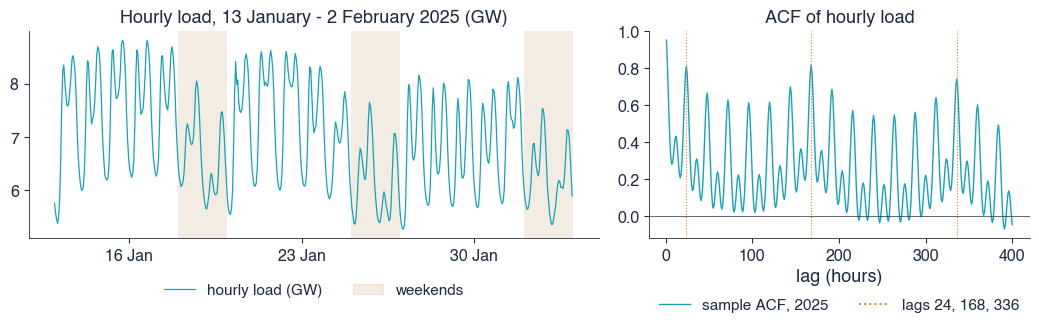

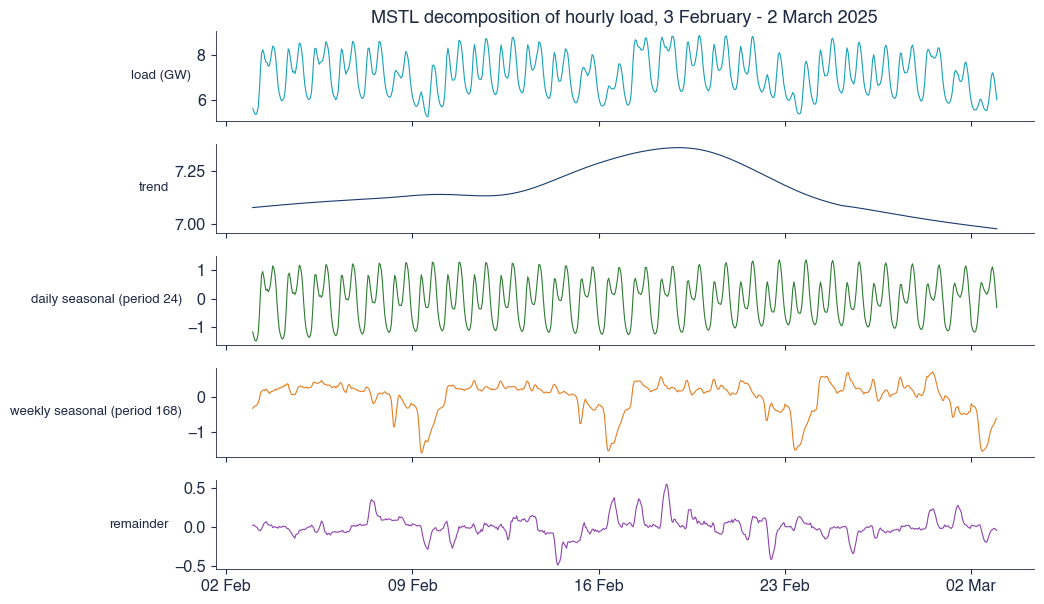

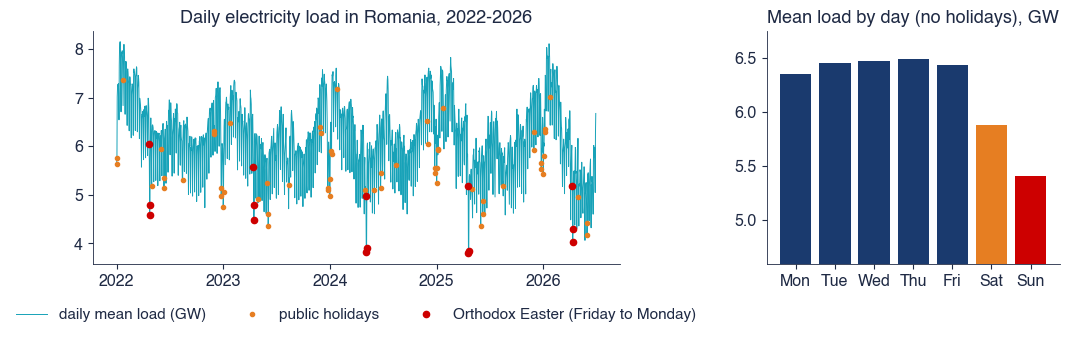

[1, 1, 1] {'sin1_365.25': 0.09, 'cos1_365.25': 0.491, 'sin2_365.25': 0.17, 'cos2_365.25': 0.284, 'sin3_365.25': -0.133, 'cos3_365.25': -0.123, 'sin4_365.25': -0.002, 'cos4_365.25': -0.038, 'mon': 0.884, 'tue': 1.054, 'wed': 1.083, 'thu': 1.083, 'fri': 1.033, 'sat': 0.502, 'easter': -0.581, 'xmas': -0.615, 'holiday': -0.382}


In [15]:
def fig_load_hourly(save_it=True):
    """Hourly load: three weeks in January 2025 and the ACF of one year of hourly data (lags up to 400 hours)."""
    s = load_hourly() / 1000
    w = s.loc['2025-01-13':'2025-02-02 23:00']
    yr = s.loc['2025-01-01':'2025-12-31']
    r = sample_acf(yr.values, 400)
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.6), gridspec_kw={'width_ratios': [1.5, 1]})
    ax[0].plot(w.index, w.values, color=st.Teal, lw=0.9, label='hourly load (GW)')
    for d in pd.date_range('2025-01-18', '2025-02-02', freq='7D'):
        ax[0].axvspan(d, d + pd.Timedelta(days=2), color=st.Amber, alpha=0.15, lw=0)
    ax[0].fill_between([], [], color=st.Amber, alpha=0.15, label='weekends')
    ax[0].set_title('Hourly load, 13 January - 2 February 2025 (GW)')
    date_axis(ax[0], 'week')
    st.legend_outside_bottom(ax[0], ncol=2, y=-0.15)
    ax[1].plot(np.arange(1, 401), r, color=st.Teal, lw=1.0, label='sample ACF, 2025')
    for m in (24, 168, 336):
        ax[1].axvline(m, color=st.Orange, lw=0.8, ls=':')
    ax[1].plot([], [], color=st.Orange, ls=':', label='lags 24, 168, 336')
    ax[1].axhline(0, color=st.DarkText, lw=0.5)
    ax[1].set_xlabel('lag (hours)')
    ax[1].set_title('ACF of hourly load')
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.22)
    plt.tight_layout()
    save('tsa_ch4_load_hourly', save_it)
    prof = yr.groupby(yr.index.hour).mean()
    return {'r12': float(r[11]), 'r24': float(r[23]), 'r168': float(r[167]), 'r84': float(r[83]),
            'peak_h': int(prof.idxmax()), 'trough_h': int(prof.idxmin()), 'peak_v': float(prof.max()),
            'trough_v': float(prof.min()), 'T_year': int(len(yr)), 'T_all': int(len(s)),
            'first': str(s.index[0].date()), 'last': str(s.index[-1].date())}


def fig_mstl(save_it=True):
    """MSTL of hourly load (four weeks, February 2025): trend, daily (24) and weekly (168) components, remainder."""
    s = (load_hourly() / 1000).loc['2025-02-03':'2025-03-02 23:00']
    res = MSTL(s.values, periods=(24, 168)).fit()
    comp = [('load (GW)', s.values, st.Teal), ('trend', res.trend, st.MainBlue),
            ('daily seasonal (period 24)', res.seasonal[:, 0], st.Forest),
            ('weekly seasonal (period 168)', res.seasonal[:, 1], st.Orange), ('remainder', res.resid, st.Purple)]
    fig, ax = plt.subplots(5, 1, figsize=(10.6, 6.2), sharex=True)
    for a, (t, v, c) in zip(ax, comp):
        a.plot(s.index, v, color=c, lw=0.8)
        a.set_ylabel(t, fontsize=9.5, rotation=0, ha='right', va='center')
    ax[0].set_title('MSTL decomposition of hourly load, 3 February - 2 March 2025')
    date_axis(ax[-1], 'week')
    plt.tight_layout()
    save('tsa_ch4_mstl', save_it)
    v = lambda x: float(np.var(x))
    tot = v(s.values - res.trend)
    return {'amp24': float(np.ptp(res.seasonal[:, 0][:24 * 7])), 'amp168': float(np.ptp(res.seasonal[:, 1][:168])),
            'share24': v(res.seasonal[:, 0]) / tot, 'share168': v(res.seasonal[:, 1]) / tot, 'share_r': v(res.resid) / tot}


def fig_load_daily(save_it=True):
    """Daily load 2022-2026 with public holidays marked, and the mean load by day of the week."""
    d = load_daily()
    H = ro_holidays(range(2022, 2027))
    hol = d.reindex(H.index).dropna()
    eas = hol[H.reindex(hol.index) == 'Easter']
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.6), gridspec_kw={'width_ratios': [1.8, 1]})
    ax[0].plot(d.index, d.values, color=st.Teal, lw=0.7, label='daily mean load (GW)')
    ax[0].plot(hol.index, hol.values, 'o', ms=3, color=st.Orange, label='public holidays')
    ax[0].plot(eas.index, eas.values, 'o', ms=4.5, color=st.IDAred, label='Orthodox Easter (Friday to Monday)')
    ax[0].set_title('Daily electricity load in Romania, 2022-2026')
    date_axis(ax[0], 'year')
    st.legend_outside_bottom(ax[0], ncol=3, y=-0.13)
    nh = d[~d.index.isin(H.index)]
    wd = nh.groupby(nh.index.dayofweek).mean()
    ax[1].bar(range(7), wd.values, color=[st.MainBlue] * 5 + [st.Orange, st.IDAred])
    ax[1].set_xticks(range(7))
    ax[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax[1].set_ylim(wd.min() * 0.85, wd.max() * 1.04)
    ax[1].set_title('Mean load by day (no holidays), GW')
    plt.tight_layout()
    save('tsa_ch4_load_daily', save_it)
    low = d.nsmallest(6)
    return {'wd': wd.round(4).tolist(), 'sun_wed': float(wd[6] / wd[2] - 1), 'sat_wed': float(wd[5] / wd[2] - 1),
            'low_days': [str(x.date()) for x in low.index], 'low_vals': low.round(3).tolist(),
            'easter_mean': float(eas.mean()), 'mean': float(d.mean()), 'n_hol': int(len(hol)),
            'jan_jul': float(d[d.index.month == 1].mean() / d[d.index.month == 5].mean() - 1)}


def dhr_fit(end=CV_FIRST, order=None):
    """The dynamic harmonic regression on daily load up to the first origin: holiday and weekday coefficients."""
    y = load_daily().loc[:end]
    order = order or select_orders(y)['dhr']
    X = load_exog(y.index)
    r = fit_sarima(y, order, (0, 0, 0, 0), exog=X.values, trend='c' if order[1] == 0 else 'n')
    nm = (['const'] if order[1] == 0 else []) + list(X.columns)
    par = dict(zip(r.param_names, map(float, r.params)))
    se = dict(zip(r.param_names, map(float, r.bse)))
    keys = [k for k in r.param_names if k.startswith('x')]
    named = {nm_: (par[k], se[k]) for nm_, k in zip(X.columns, keys)}
    e = r.resid[10:]
    return {'order': list(order), 'coef': {k: v[0] for k, v in named.items()}, 'se': {k: v[1] for k, v in named.items()},
            'ar': [par[k] for k in r.param_names if k.startswith('ar.')], 'ma': [par[k] for k in r.param_names if k.startswith('ma.')],
            'sigma': float(np.sqrt(par['sigma2'])), 'lb14': ljung_box(e, 14, 14 - sum(order[::2])), 'k': int(len(r.params)),
            'aic': float(r.aic)}


fig_load_hourly(save_it=False)
fig_mstl(save_it=False)
fig_load_daily(save_it=False)
dhr = dhr_fit()
print(dhr['order'], {k: round(v, 3) for k, v in dhr['coef'].items()})

## 9. TBATS and Prophet (optional packages)

12:54:17 - cmdstanpy - INFO - Chain [1] start processing


12:54:18 - cmdstanpy - INFO - Chain [1] done processing


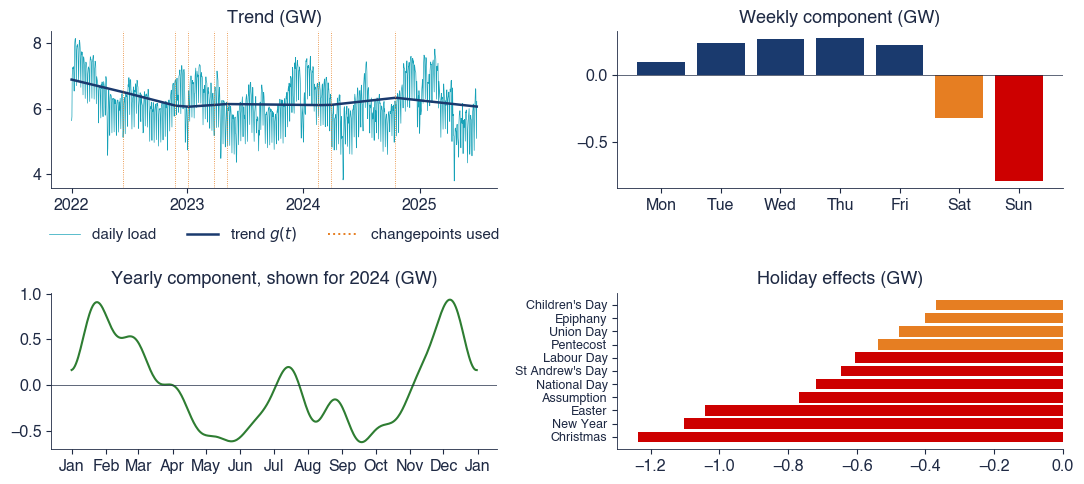

{'weekly': [0.098, 0.241, 0.2736, 0.2779, 0.2255, -0.3194, -0.7967], 'yearly_max': 0.9337710643323388, 'yearly_min': -0.6185538622998248, 'yearly_argmax': '2024-12-07', 'yearly_argmin': '2024-09-18', 'hol': {'Christmas': -1.2351, 'New Year': -1.1022, 'Easter': -1.0402, 'Assumption': -0.7691, 'National Day': -0.7193, "St Andrew's Day": -0.6462, 'Labour Day': -0.6058, 'Pentecost': -0.5371, 'Union Day': -0.4781, 'Epiphany': -0.4001, "Children's Day": -0.3699}, 'trend0': 6.8914743830388545, 'trend1': 6.06747932058397, 'n_cp': 25}


{'harmonics': [3, 9], 'p': 1, 'q': 2, 'aic': 5257.630360239142, 'alpha': 0.9613219029375434, 'n_states': 28}


In [16]:
def fig_prophet_components(save_it=True, end=CV_FIRST):
    """Prophet on daily load up to the first forecast origin: trend, weekly and yearly components, holiday effects."""
    if not have('prophet'):
        return {}
    from prophet import Prophet
    y = load_daily().loc[:end]
    H = ro_holidays(range(2022, 2027))
    p = Prophet(holidays=pd.DataFrame({'ds': H.index, 'holiday': H.values}), daily_seasonality=False)
    p.fit(pd.DataFrame({'ds': y.index, 'y': y.values}))
    fut = p.make_future_dataframe(periods=0)
    c = p.predict(fut)
    fig, ax = plt.subplots(2, 2, figsize=(11.0, 5.0))
    ax[0, 0].plot(y.index, y.values, color=st.Teal, lw=0.5, label='daily load')
    ax[0, 0].plot(c['ds'], c['trend'], color=st.MainBlue, lw=1.8, label='trend $g(t)$')
    for cp in p.changepoints[np.abs(np.nanmean(p.params['delta'], axis=0)) > 0.01]:
        ax[0, 0].axvline(cp, color=st.Orange, lw=0.6, ls=':')
    ax[0, 0].plot([], [], color=st.Orange, ls=':', label='changepoints used')
    ax[0, 0].set_title('Trend (GW)')
    date_axis(ax[0, 0], 'year')
    st.legend_outside_bottom(ax[0, 0], ncol=3, y=-0.15)
    wk = c.groupby(c['ds'].dt.dayofweek)['weekly'].mean()
    ax[0, 1].bar(range(7), wk.values, color=[st.MainBlue] * 5 + [st.Orange, st.IDAred])
    ax[0, 1].set_xticks(range(7))
    ax[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax[0, 1].axhline(0, color=st.DarkText, lw=0.5)
    ax[0, 1].set_title('Weekly component (GW)')
    yr = c[(c['ds'] >= '2024-01-01') & (c['ds'] <= '2024-12-31')]
    ax[1, 0].plot(yr['ds'], yr['yearly'], color=st.Forest, lw=1.5)
    ax[1, 0].axhline(0, color=st.DarkText, lw=0.5)
    ax[1, 0].set_title('Yearly component, shown for 2024 (GW)')
    date_axis(ax[1, 0], 'month')
    hn = [h for h in p.train_holiday_names]
    eff = pd.Series({h: c.loc[c[h] != 0, h].mean() if (c[h] != 0).any() else 0.0 for h in hn}).sort_values()
    ax[1, 1].barh(range(len(eff)), eff.values, color=[st.IDAred if v < -0.6 else st.Orange for v in eff.values])
    ax[1, 1].set_yticks(range(len(eff)))
    ax[1, 1].set_yticklabels(eff.index, fontsize=9)
    ax[1, 1].axvline(0, color=st.DarkText, lw=0.5)
    ax[1, 1].set_title('Holiday effects (GW)')
    plt.tight_layout()
    save('tsa_ch4_prophet', save_it)
    return {'weekly': wk.round(4).tolist(), 'yearly_max': float(yr['yearly'].max()), 'yearly_min': float(yr['yearly'].min()),
            'yearly_argmax': str(yr.loc[yr['yearly'].idxmax(), 'ds'].date()), 'yearly_argmin': str(yr.loc[yr['yearly'].idxmin(), 'ds'].date()),
            'hol': eff.round(4).to_dict(), 'trend0': float(c['trend'].iloc[0]), 'trend1': float(c['trend'].iloc[-1]),
            'n_cp': int(len(p.changepoints))}


def tbats_fit(end=CV_FIRST):
    """TBATS(7, 365.25) on daily load up to the first origin: chosen harmonics, ARMA orders, AIC."""
    if not have('tbats'):
        return {}
    from tbats import TBATS
    y = load_daily().loc[:end]
    m = TBATS(seasonal_periods=[7, 365.25], use_box_cox=False, use_trend=False, use_damped_trend=False,
              use_arma_errors=True, n_jobs=1).fit(y.values)
    p = m.params
    return {'harmonics': [int(k) for k in p.components.seasonal_harmonics], 'p': int(len(p.ar_coefs)),
            'q': int(len(p.ma_coefs)), 'aic': float(m.aic), 'alpha': float(p.alpha),
            'n_states': int(1 + 2 * sum(p.components.seasonal_harmonics) + len(p.ar_coefs) + len(p.ma_coefs))}


print(fig_prophet_components(save_it=False))
print(tbats_fit())

## 10. Forecast evaluation and combination

- `FAST = True`: an origin every 56 days (a few minutes); `FAST = False`: every 14 days, the 26 origins of the slides (about 10 minutes, TBATS is refitted at each origin).

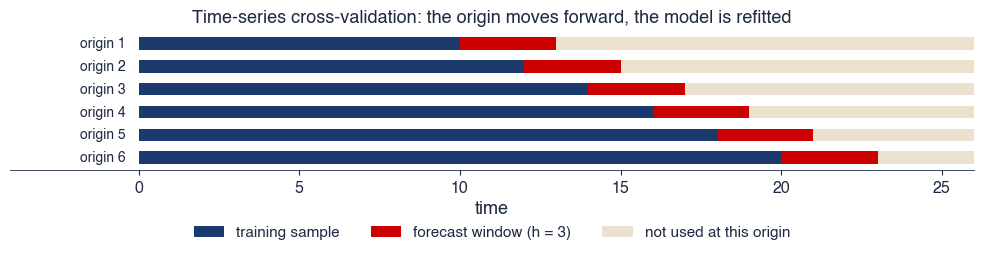

12:55:18 - cmdstanpy - INFO - Chain [1] start processing


12:55:18 - cmdstanpy - INFO - Chain [1] done processing


12:55:50 - cmdstanpy - INFO - Chain [1] start processing


12:55:50 - cmdstanpy - INFO - Chain [1] done processing


12:56:17 - cmdstanpy - INFO - Chain [1] start processing


...

12:57:20 - cmdstanpy - INFO - Chain [1] done processing


12:57:44 - cmdstanpy - INFO - Chain [1] start processing


12:57:44 - cmdstanpy - INFO - Chain [1] done processing


orders: {'sarima': (2, 0, 1), 'dhr': (1, 1, 1)}  best single model: DHR


,MAE,RMSE,MASE
model,,,
Seasonal naive,0.3560,0.4881,1.1521
ETS,0.3859,0.5223,1.2489
SARIMA,0.2996,0.4053,0.9695
DHR,0.2373,0.3066,0.7678
TBATS,0.3633,0.4817,1.1756
Prophet,0.2891,0.3665,0.9354
Combination,0.2540,0.3333,0.8221


In [17]:
FAST = True


def load_cv(first=CV_FIRST, step=CV_STEP, h=CV_H, n_origins=None, models=None, save_csv=True):
    """Time-series cross-validation on daily load: expanding training window, forecast origins every `step` days from
    `first`, horizon h. Returns the errors of every model at every origin and horizon."""
    y = load_daily()
    orders = select_orders(y.loc[:first])
    origins = [o for o in pd.date_range(first, y.index[-1] - pd.Timedelta(days=h), freq=f'{step}D')]
    if n_origins:
        origins = origins[:n_origins]
    rows = []
    for o in origins:
        idx, f = forecast_models(y.loc[:o], h, orders, models)
        act = y.reindex(idx).values
        for k, v in f.items():
            for j in range(h):
                rows.append({'origin': o, 'model': k, 'h': j + 1, 'date': idx[j], 'actual': act[j], 'fc': v[j],
                             'err': act[j] - v[j]})
    E = pd.DataFrame(rows)
    if save_csv:
        E.round(5).to_csv(os.path.join(HERE, 'ch4_load_cv.csv'), index=False)
    return E, orders


def cv_summary(E, y=None):
    """MAE, RMSE (GW), MASE (scaled by the in-sample MAE of the weekly seasonal naive method on the first training
    sample), by model; Diebold-Mariano tests on window-average losses (one value per origin)."""
    y = load_daily() if y is None else y
    first = E['origin'].min()
    tr = y.loc[:first].values
    scale = np.mean(np.abs(tr[7:] - tr[:-7]))
    g = E.groupby('model')['err']
    tab = pd.DataFrame({'MAE': g.apply(lambda e: np.mean(np.abs(e))), 'RMSE': g.apply(lambda e: np.sqrt(np.mean(e ** 2)))})
    tab['MASE'] = tab['MAE'] / scale
    order = [m for m in ['Seasonal naive', 'ETS', 'SARIMA', 'DHR', 'TBATS', 'Prophet', 'Combination'] if m in tab.index]
    tab = tab.loc[order]
    W = E.assign(se=E['err'] ** 2, ae=E['err'].abs()).groupby(['model', 'origin'])[['se', 'ae']].mean()
    best = tab['MAE'].drop('Combination', errors='ignore').idxmin()
    dm = {}
    for m in order:
        for ref in ['Seasonal naive', 'Combination', best]:
            if m == ref:
                continue
            a, b = W.loc[m], W.loc[ref]
            dm[f'{m}|{ref}|ae'] = dm_raw(a['ae'].values, b['ae'].values)
            dm[f'{m}|{ref}|se'] = dm_raw(a['se'].values, b['se'].values)
    byh = E.assign(ae=E['err'].abs()).groupby(['model', 'h'])['ae'].mean().unstack(0)
    return tab, dm, best, scale, byh


def fig_cv_scheme(save_it=True, n=6):
    """The expanding-window (rolling-origin) scheme of time-series cross-validation."""
    fig, ax = plt.subplots(figsize=(10.0, 3.0))
    for i in range(n):
        tr_end = 10 + 2 * i
        ax.barh(i, tr_end, left=0, color=st.MainBlue, height=0.55, label='training sample' if i == 0 else '_nolegend_')
        ax.barh(i, 3, left=tr_end, color=st.IDAred, height=0.55, label='forecast window (h = 3)' if i == 0 else '_nolegend_')
        ax.barh(i, 26 - tr_end - 3, left=tr_end + 3, color=st.Amber, alpha=0.25, height=0.55,
                label='not used at this origin' if i == 0 else '_nolegend_')
        ax.text(-0.4, i, f'origin {i + 1}', ha='right', va='center', fontsize=10, color=st.DarkText)
    ax.set_yticks([])
    ax.invert_yaxis()
    ax.set_xlim(-4, 26)
    ax.set_xlabel('time')
    ax.spines['left'].set_visible(False)
    ax.set_title('Time-series cross-validation: the origin moves forward, the model is refitted')
    st.legend_outside_bottom(ax, ncol=3, y=-0.3)
    plt.tight_layout()
    save('tsa_ch4_cv_scheme', save_it)
    return {'n': n}


def fig_cv_results(tab, byh, save_it=True):
    """MAE by model (bars) and MAE by horizon (lines)."""
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.7), gridspec_kw={'width_ratios': [1, 1.3]})
    ax[0].barh(range(len(tab)), tab['MAE'].values * 1000, color=[MODEL_COL[m] for m in tab.index])
    ax[0].set_yticks(range(len(tab)))
    ax[0].set_yticklabels(tab.index)
    ax[0].invert_yaxis()
    ax[0].set_xlabel('MAE (MW)')
    ax[0].set_title('Mean absolute error, all origins and horizons')
    for i, v in enumerate(tab['MAE'].values * 1000):
        ax[0].text(v + 4, i, f'{v:.0f}', va='center', fontsize=9.5, color=st.DarkText)
    for m in byh.columns:
        ax[1].plot(byh.index, byh[m].values * 1000, color=MODEL_COL[m], lw=1.8 if m == 'Combination' else 1.2,
                   ls='--' if m == 'Seasonal naive' else '-', marker='o', ms=2.5, label=m)
    ax[1].set_xlabel('horizon h (days)')
    ax[1].set_ylabel('MAE (MW)')
    ax[1].set_title('MAE by forecast horizon')
    st.legend_outside_bottom(ax[1], ncol=4, y=-0.2)
    plt.tight_layout()
    save('tsa_ch4_cv_results', save_it)


def fig_load_forecasts(E, origin=None, save_it=True):
    """Forecasts of the models from one origin against the actual daily load (the window with Easter if present)."""
    y = load_daily()
    if origin is None:
        eas = pd.Timestamp(easter(2026, EASTER_ORTHODOX))
        cand = [o for o in sorted(E['origin'].unique()) if o < eas <= o + pd.Timedelta(days=CV_H)]
        origin = cand[0] if cand else sorted(E['origin'].unique())[-1]
    sub = E[E['origin'] == origin]
    fig, ax = plt.subplots(figsize=(10.6, 3.8))
    hist = y.loc[origin - pd.Timedelta(days=27):origin + pd.Timedelta(days=CV_H)]
    ax.plot(hist.index, hist.values, color=st.DarkText, lw=1.6, marker='o', ms=2.5, label='actual load')
    for m in ['Seasonal naive', 'SARIMA', 'DHR', 'TBATS', 'Prophet', 'Combination']:
        s = sub[sub['model'] == m]
        if len(s):
            ax.plot(s['date'], s['fc'], color=MODEL_COL[m], lw=1.3, ls='--' if m == 'Seasonal naive' else '-', label=m)
    ax.axvline(origin + pd.Timedelta(hours=12), color=st.DarkText, lw=0.6, ls=':')
    ax.set_title(f'Daily load (GW): forecasts made on {origin.strftime("%d %B %Y")}, 14 days')
    date_axis(ax, 'week')
    st.legend_outside_bottom(ax, ncol=4, y=-0.13)
    plt.tight_layout()
    save('tsa_ch4_load_fc', save_it)
    acc = sub.assign(ae=sub['err'].abs()).groupby('model')['ae'].mean()
    return {'origin': str(pd.Timestamp(origin).date()), 'mae': acc.round(4).to_dict()}


def fig_combination(E, m1='DHR', m2='Prophet', save_it=True):
    """MAE of the combination w f1 + (1 - w) f2 as a function of the weight w, on the cross-validation errors."""
    a = E[E['model'] == m1].sort_values(['origin', 'h'])
    b = E[E['model'] == m2].sort_values(['origin', 'h'])
    act = a['actual'].values
    w = np.linspace(0, 1, 101)
    mae = [np.mean(np.abs(act - (x * a['fc'].values + (1 - x) * b['fc'].values))) * 1000 for x in w]
    rm = [np.sqrt(np.mean((act - (x * a['fc'].values + (1 - x) * b['fc'].values)) ** 2)) * 1000 for x in w]
    fig, ax = plt.subplots(figsize=(8.6, 3.4))
    ax.plot(w, mae, color=st.MainBlue, lw=1.6, label='MAE (MW)')
    ax.plot(w, rm, color=st.IDAred, lw=1.6, label='RMSE (MW)')
    ax.axvline(0.5, color=st.Forest, lw=0.9, ls='--', label='equal weights')
    ax.set_xlabel(f'weight w of {m1} (1 - w on {m2})')
    ax.set_title(f'Combining {m1} and {m2}: error as a function of the weight')
    st.legend_outside_bottom(ax, ncol=3, y=-0.25)
    plt.tight_layout()
    save('tsa_ch4_combination', save_it)
    e1, e2 = act - a['fc'].values, act - b['fc'].values
    return {'mae_w0': mae[0], 'mae_w1': mae[-1], 'mae_half': mae[50], 'w_best': float(w[int(np.argmin(mae))]),
            'mae_best': float(min(mae)), 'rmse_half': rm[50], 'rmse_w0': rm[0], 'rmse_w1': rm[-1],
            'corr': float(np.corrcoef(e1, e2)[0, 1]), 'sd1': float(e1.std() * 1000), 'sd2': float(e2.std() * 1000)}


fig_cv_scheme(save_it=False)
E, orders = load_cv(step=56 if FAST else CV_STEP, save_csv=False)
tab, dm, best, scale, byh = cv_summary(E)
print('orders:', orders, ' best single model:', best)
tab.round(4)

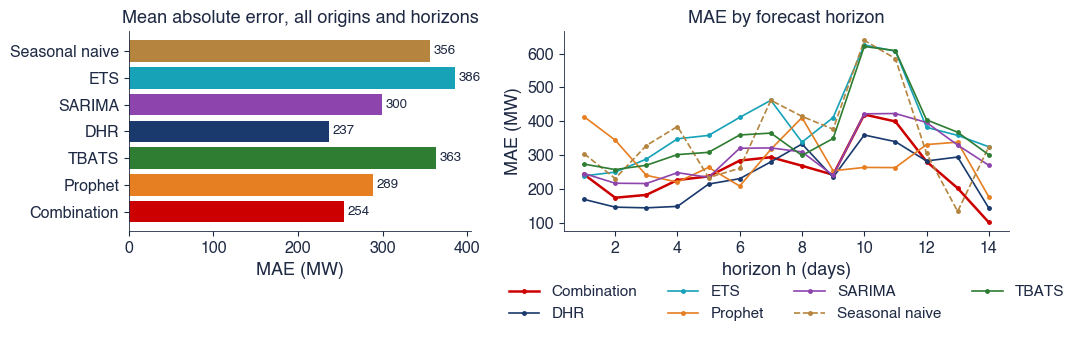

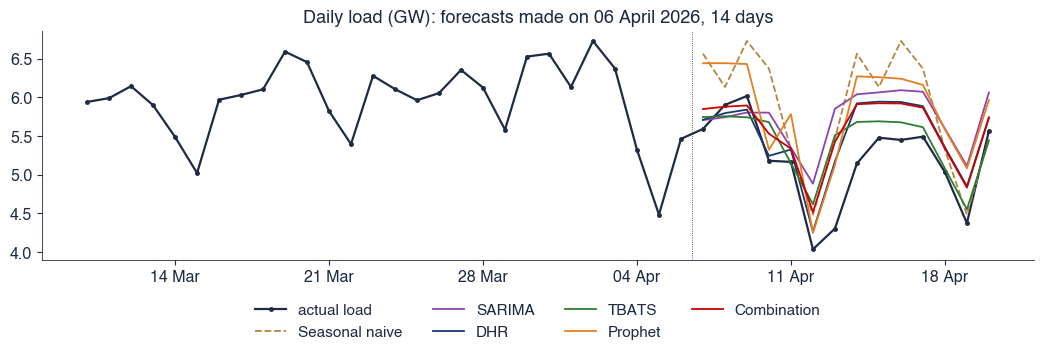

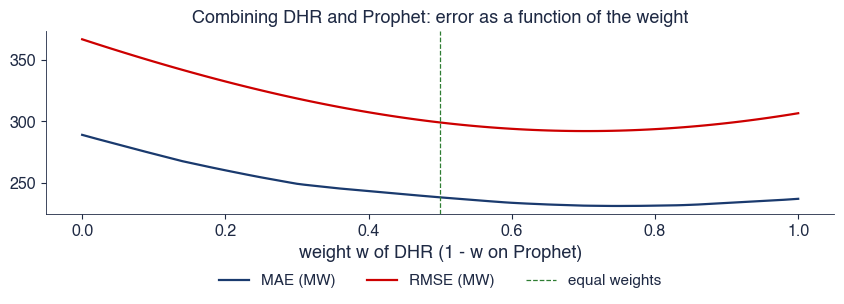

,hln,p
Seasonal naive|Combination|se,2.037,0.088
Seasonal naive|DHR|se,1.951,0.099
ETS|Seasonal naive|se,0.298,0.776
ETS|Combination|se,1.701,0.140
ETS|DHR|se,1.704,0.139
SARIMA|Seasonal naive|se,-2.071,0.084
SARIMA|Combination|se,1.578,0.166
SARIMA|DHR|se,1.601,0.160
DHR|Seasonal naive|se,-1.951,0.099
DHR|Combination|se,-1.093,0.316


In [18]:
fig_cv_results(tab, byh, save_it=False)
fig_load_forecasts(E, save_it=False)
comb = fig_combination(E, 'DHR', 'Prophet', save_it=False) if 'Prophet' in tab.index else {}
pd.DataFrame({k: v for k, v in dm.items() if k.endswith('|se')}).T[['hln', 'p']].round(3)

In [19]:
def gdp_cv(first='2012-10-01', H=4):
    """Rolling-origin forecasts of 100 ln GDP (not adjusted), expanding window: SARIMA airline (0,1,1)(0,1,1)_4,
    ETS (additive damped trend, additive seasonality) on the log, seasonal naive; errors in % (log points)."""
    y = 100 * eurostat_log(GDP_NSA, GDP_START)
    rows = []
    for i in range(len(y)):
        o = y.index[i]
        if o < pd.Timestamp(first) or i + H >= len(y):
            continue
        tr = y.iloc[:i + 1]
        act = y.iloc[i + 1:i + 1 + H].values
        f = {'SARIMA': fit_sarima(tr, (0, 1, 1), (0, 1, 1, 4)).forecast(H),
             'ETS': ExponentialSmoothing(tr.values, trend='add', damped_trend=True, seasonal='add', seasonal_periods=4).fit().forecast(H),
             'Seasonal naive': tr.values[-4:][:H] + 0.0}
        f['Combination'] = (f['SARIMA'] + f['ETS']) / 2
        for k, v in f.items():
            for j in range(H):
                rows.append({'origin': o, 'model': k, 'h': j + 1, 'err': act[j] - v[j]})
    E = pd.DataFrame(rows)
    out = {'first': str(E['origin'].min().date()), 'last': str(E['origin'].max().date()), 'n': int(E['origin'].nunique())}
    tab = {}
    for (m, h), g in E.groupby(['model', 'h']):
        tab.setdefault(m, {})[int(h)] = {'mae': float(g['err'].abs().mean()), 'rmse': float(np.sqrt((g['err'] ** 2).mean()))}
    out['tab'] = tab
    ex = E[~E['origin'].between('2019-01-01', '2020-12-31')]
    out['tab_ex'] = {m: {int(h): float(g['err'].abs().mean()) for h, g in gm.groupby('h')} for m, gm in ex.groupby('model')}
    out['n_ex'] = int(ex['origin'].nunique())
    dm = {}
    for h in (1, 4):
        a = E[(E['model'] == 'SARIMA') & (E['h'] == h)].sort_values('origin')['err'].values
        for ref in ['ETS', 'Seasonal naive']:
            b = E[(E['model'] == ref) & (E['h'] == h)].sort_values('origin')['err'].values
            dm[f'h{h}|{ref}'] = dm_test(a, b, h=h, loss='se')
    out['dm'] = dm
    return out


gc = gdp_cv()
pd.DataFrame({m: {h: v['mae'] for h, v in d.items()} for m, d in gc['tab'].items()}).round(3)

,Combination,ETS,SARIMA,Seasonal naive
1,1.703,1.763,1.693,3.814
2,2.150,2.201,2.188,3.753
3,2.424,2.510,2.542,3.743
4,2.646,2.838,2.701,3.735


## Exercises

1. Fit the airline model to Romanian industrial production (`IPI`) with and without `working_days` as a regressor. Which one passes Ljung–Box?
2. Add the Easter regressor to the DHR of daily load as a 7-day window before Easter and compare the cross-validation MAE.
3. Combine DHR and Prophet with the weight estimated on the first half of the origins only, and evaluate it on the second half.